<a href="https://colab.research.google.com/github/teluguvenkatesh1018-gif/AIEC/blob/main/exercise1_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip install numpy pandas scikit-learn

In [10]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [13]:
import pandas as pd

df = pd.read_csv("data_banknote_authentication.txt", header=None)

df.head()

,0,1,2,3,4
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [14]:
print(df.shape)

(1372, 5)


In [15]:
print(df.head())

         0       1       2        3  4
0  3.62160  8.6661 -2.8073 -0.44699  0
1  4.54590  8.1674 -2.4586 -1.46210  0
2  3.86600 -2.6383  1.9242  0.10645  0
3  3.45660  9.5228 -4.0112 -3.59440  0
4  0.32924 -4.4552  4.5718 -0.98880  0


In [16]:
print(df.head())

         0       1       2        3  4
0  3.62160  8.6661 -2.8073 -0.44699  0
1  4.54590  8.1674 -2.4586 -1.46210  0
2  3.86600 -2.6383  1.9242  0.10645  0
3  3.45660  9.5228 -4.0112 -3.59440  0
4  0.32924 -4.4552  4.5718 -0.98880  0


In [17]:
df.columns = ["variance", "skewness", "curtosis", "entropy", "class"]

df.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [18]:
df["class"].value_counts()

,count
class,
0,762
1,610


In [21]:
X = df[["variance", "skewness", "curtosis", "entropy"]].values
y = df["class"].values

In [22]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1372, 4)
y shape: (1372,)


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1097, 4)
Testing data: (275, 4)


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nFirst training sample:")
print(X_train[0])

print("\nActual class:")
print(y_train[0])

X_train: (1097, 4)
X_test: (275, 4)
y_train: (1097,)
y_test: (275,)

First training sample:
[ 0.39687699  0.05746643 -1.03953765  0.51951506]

Actual class:
1


In [33]:
class Perceptron:

    def __init__(self, learning_rate=0.1, max_epochs=1000):
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.weights = None
        self.bias = 0
        self.epochs = 0
        self.converged = False

In [34]:
model = Perceptron()

In [35]:
def step_function(z):
    return 1 if z >= 0 else 0

In [38]:
print(step_function(5))
print(step_function(-2))
print(step_function(0))

1
0
1


In [42]:
class Perceptron:

    def __init__(self, learning_rate=0.1, max_epochs=1000):
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.weights = None
        self.bias = 0
        self.epochs = 0
        self.converged = False

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        for epoch in range(self.max_epochs):

            errors = 0

            for xi, target in zip(X, y):

                weighted_sum = np.dot(xi, self.weights) + self.bias

                prediction = step_function(weighted_sum)

                error = target - prediction

                self.weights += self.learning_rate * error * xi
                self.bias += self.learning_rate * error

                if error != 0:
                    errors += 1

            self.epochs = epoch + 1

            if errors == 0:
                self.converged = True
                break

    def predict(self, X):
        weighted_sums = np.dot(X, self.weights) + self.bias
        predictions = (weighted_sums >= 0).astype(int)

        return predictions, weighted_sums

In [43]:
model = Perceptron(
    learning_rate=0.1,
    max_epochs=1000
)

model.fit(X_train, y_train)

In [44]:
print("Weights:", model.weights)
print("Bias:", model.bias)
print("Epochs:", model.epochs)
print("Converged:", model.converged)

Weights: [-2.77776075 -3.28262785 -3.05945493 -0.11574033]
Bias: -1.3
Epochs: 1000
Converged: False


In [45]:
predictions, weighted_sums = model.predict(X_test)

In [46]:
accuracy = np.mean(predictions == y_test) * 100

print("Accuracy:", accuracy, "%")

Accuracy: 98.54545454545455 %


In [47]:
print("Actual:", y_test[:10])
print("Predicted:", predictions[:10])
print("Weighted Sum:", weighted_sums[:10])

Actual: [0 1 0 1 1 1 0 0 0 1]
Predicted: [0 1 0 1 1 1 0 0 0 1]
Weighted Sum: [-5.28252665  1.76262081 -0.35909437  1.54997149  2.48809677  1.21431261
 -4.99267773 -5.59042012 -4.3271968   0.47850764]


In [48]:
feature_names = ["variance", "skewness", "curtosis", "entropy"]

In [49]:
feature1 = 0
feature2 = 1

In [50]:
feature1 = 0
feature2 = 1

X_pair = X[:, [feature1, feature2]]

In [51]:
print("Selected features:")
print(feature_names[feature1])
print(feature_names[feature2])

print("Shape:", X_pair.shape)

Selected features:
variance
skewness
Shape: (1372, 2)


In [52]:
X_pair_train, X_pair_test, y_pair_train, y_pair_test = train_test_split(
    X_pair,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [53]:
pair_scaler = StandardScaler()

X_pair_train = pair_scaler.fit_transform(X_pair_train)
X_pair_test = pair_scaler.transform(X_pair_test)

In [54]:
pair_model = Perceptron(
    learning_rate=0.1,
    max_epochs=1000
)

pair_model.fit(X_pair_train, y_pair_train)

In [55]:
print("Feature 1:", feature_names[feature1])
print("Feature 2:", feature_names[feature2])

print("Weight 1:", pair_model.weights[0])
print("Weight 2:", pair_model.weights[1])
print("Bias:", pair_model.bias)
print("Epochs:", pair_model.epochs)
print("Converged:", pair_model.converged)

Feature 1: variance
Feature 2: skewness
Weight 1: -0.20468880057458355
Weight 2: -0.1473767080195666
Bias: -2.7755575615628914e-17
Epochs: 1000
Converged: False


In [56]:
w1 = pair_model.weights[0]
w2 = pair_model.weights[1]
b = pair_model.bias

print(
    f"Decision Boundary: {w1:.4f}*x1 + {w2:.4f}*x2 + {b:.4f} = 0"
)

Decision Boundary: -0.2047*x1 + -0.1474*x2 + -0.0000 = 0


In [57]:
print(
    f"x2 = (-({w1:.4f})*x1 - ({b:.4f})) / ({w2:.4f})"
)

x2 = (-(-0.2047)*x1 - (-0.0000)) / (-0.1474)


In [58]:
pair_predictions, pair_weighted_sums = pair_model.predict(X_pair_test)

In [59]:
sides = np.where(
    pair_weighted_sums >= 0,
    "Class 1 side",
    "Class 0 side"
)

In [60]:
results = pd.DataFrame({
    "Actual Class": y_pair_test,
    "Predicted Class": pair_predictions,
    "Weighted Sum": pair_weighted_sums,
    "Boundary Side": sides
})

results.head(10)

,Actual Class,Predicted Class,Weighted Sum,Boundary Side
0,0,0,-0.277789,Class 0 side
1,1,1,0.130784,Class 1 side
2,0,0,-0.101891,Class 0 side
3,1,1,0.096038,Class 1 side
4,1,1,0.408625,Class 1 side
5,1,0,-0.132104,Class 0 side
6,0,0,-0.281493,Class 0 side
7,0,0,-0.419714,Class 0 side
8,0,0,-0.039430,Class 0 side
9,1,1,0.633824,Class 1 side


In [61]:
pair_accuracy = np.mean(pair_predictions == y_pair_test) * 100

print(f"Accuracy: {pair_accuracy:.2f}%")

Accuracy: 87.64%


In [62]:
import matplotlib.pyplot as plt

In [63]:
x_min = X_pair_train[:, 0].min() - 1
x_max = X_pair_train[:, 0].max() + 1

x_values = np.linspace(x_min, x_max, 100)

y_values = (-w1 * x_values - b) / w2

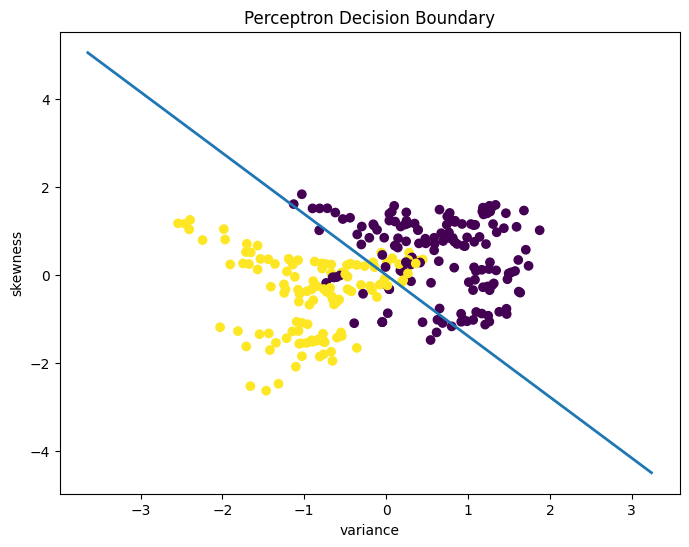

In [64]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pair_test[:, 0],
    X_pair_test[:, 1],
    c=y_pair_test
)

plt.plot(
    x_values,
    y_values,
    linewidth=2
)

plt.xlabel(feature_names[feature1])
plt.ylabel(feature_names[feature2])
plt.title("Perceptron Decision Boundary")

plt.show()

In [65]:
def decision_boundary_explorer():
    feature_names = ["variance", "skewness", "curtosis", "entropy"]

    print("\nAvailable Features:")
    for i, name in enumerate(feature_names):
        print(i, "-", name)

    feature1 = int(input("Select first feature: "))
    feature2 = int(input("Select second feature: "))

    X_pair = X[:, [feature1, feature2]]

    X_pair_train, X_pair_test, y_pair_train, y_pair_test = train_test_split(
        X_pair,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    pair_scaler = StandardScaler()

    X_pair_train = pair_scaler.fit_transform(X_pair_train)
    X_pair_test = pair_scaler.transform(X_pair_test)

    model = Perceptron(
        learning_rate=0.1,
        max_epochs=1000
    )

    model.fit(X_pair_train, y_pair_train)

    predictions, weighted_sums = model.predict(X_pair_test)

    w1 = model.weights[0]
    w2 = model.weights[1]
    b = model.bias

    print("\nSelected Features:")
    print(feature_names[feature1])
    print(feature_names[feature2])

    print("\nFinal Weights:", model.weights)
    print("Bias:", b)
    print("Epochs:", model.epochs)
    print("Converged:", model.converged)

    print(
        f"\nDecision Boundary: "
        f"{w1:.4f}*x1 + {w2:.4f}*x2 + {b:.4f} = 0"
    )

    sides = np.where(
        weighted_sums >= 0,
        "Class 1 side",
        "Class 0 side"
    )

    results = pd.DataFrame({
        "Actual": y_pair_test,
        "Predicted": predictions,
        "Weighted Sum": weighted_sums,
        "Boundary Side": sides
    })

    print("\nTest Sample Results:")
    display(results)

    accuracy = np.mean(predictions == y_pair_test) * 100

    print(f"\nAccuracy: {accuracy:.2f}%")

    x_min = X_pair_train[:, 0].min() - 1
    x_max = X_pair_train[:, 0].max() + 1

    x_values = np.linspace(x_min, x_max, 100)

    if w2 != 0:
        y_values = (-w1 * x_values - b) / w2

        plt.figure(figsize=(8, 6))

        plt.scatter(
            X_pair_test[:, 0],
            X_pair_test[:, 1],
            c=y_pair_test
        )

        plt.plot(x_values, y_values, linewidth=2)

        plt.xlabel(feature_names[feature1])
        plt.ylabel(feature_names[feature2])
        plt.title("Perceptron Decision Boundary")

        plt.show()

In [66]:
from itertools import combinations

def feature_pair_separability():

    feature_names = [
        "Variance",
        "Skewness",
        "Curtosis",
        "Entropy"
    ]

    results = []

    feature_pairs = list(combinations(range(4), 2))

    print("\n" + "=" * 70)
    print("       FEATURE PAIR SEPARABILITY CHALLENGE")
    print("=" * 70)

    for feature1, feature2 in feature_pairs:

        selected_features = [feature1, feature2]

        X_pair = X[:, selected_features]

        X_train_pair, X_test_pair, y_train_pair, y_test_pair = train_test_split(
            X_pair,
            y,
            test_size=0.2,
            random_state=42,
            stratify=y
        )

        scaler_pair = StandardScaler()

        X_train_pair = scaler_pair.fit_transform(X_train_pair)
        X_test_pair = scaler_pair.transform(X_test_pair)

        model = Perceptron(
            learning_rate=0.1,
            max_epochs=1000
        )

        model.fit(X_train_pair, y_train_pair)

        predictions, weighted_sums = model.predict(X_test_pair)

        accuracy = np.mean(predictions == y_test_pair) * 100

        misclassified = np.sum(predictions != y_test_pair)

        results.append({
            "Feature Pair":
                feature_names[feature1] + " + " + feature_names[feature2],
            "Epochs": model.epochs,
            "Accuracy (%)": accuracy,
            "Misclassified": misclassified,
            "Converged": model.converged,
            "Weights": model.weights.copy(),
            "Bias": model.bias
        })

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        by="Accuracy (%)",
        ascending=False
    ).reset_index(drop=True)

    print("\nResults:")
    display(
        results_df[
            [
                "Feature Pair",
                "Epochs",
                "Accuracy (%)",
                "Misclassified",
                "Converged"
            ]
        ]
    )

    print("\n" + "=" * 70)
    print("RANKING OF FEATURE PAIRS")
    print("=" * 70)

    for index, row in results_df.iterrows():

        print(
            f"{index + 1}. {row['Feature Pair']} | "
            f"Accuracy: {row['Accuracy (%)']:.2f}% | "
            f"Epochs: {row['Epochs']} | "
            f"Misclassified: {row['Misclassified']}"
        )

    best_pair = results_df.iloc[0]

    print("\n" + "=" * 70)
    print("BEST FEATURE PAIR")
    print("=" * 70)

    print("Feature Pair:", best_pair["Feature Pair"])
    print(f"Accuracy: {best_pair['Accuracy (%)']:.2f}%")
    print("Epochs:", best_pair["Epochs"])
    print("Misclassified:", best_pair["Misclassified"])
    print("Converged:", best_pair["Converged"])

In [67]:
feature_pair_separability()


       FEATURE PAIR SEPARABILITY CHALLENGE

Results:


,Feature Pair,Epochs,Accuracy (%),Misclassified,Converged
0,Variance + Skewness,1000,87.636364,34,False
1,Variance + Entropy,1000,82.909091,47,False
2,Variance + Curtosis,1000,81.454545,51,False
3,Skewness + Curtosis,1000,69.090909,85,False
4,Skewness + Entropy,1000,62.909091,102,False
5,Curtosis + Entropy,1000,48.363636,142,False



RANKING OF FEATURE PAIRS
1. Variance + Skewness | Accuracy: 87.64% | Epochs: 1000 | Misclassified: 34
2. Variance + Entropy | Accuracy: 82.91% | Epochs: 1000 | Misclassified: 47
3. Variance + Curtosis | Accuracy: 81.45% | Epochs: 1000 | Misclassified: 51
4. Skewness + Curtosis | Accuracy: 69.09% | Epochs: 1000 | Misclassified: 85
5. Skewness + Entropy | Accuracy: 62.91% | Epochs: 1000 | Misclassified: 102
6. Curtosis + Entropy | Accuracy: 48.36% | Epochs: 1000 | Misclassified: 142

BEST FEATURE PAIR
Feature Pair: Variance + Skewness
Accuracy: 87.64%
Epochs: 1000
Misclassified: 34
Converged: False


In [70]:
feature_pairs = list(combinations(range(4), 2))

In [75]:
selected_features = [feature1, feature2]
X_pair = X[:, selected_features]

In [73]:
selected_features = [0, 2]

In [77]:
model = Perceptron(
    learning_rate=0.1,
    max_epochs=1000
)

In [79]:
from itertools import combinations

def feature_pair_separability():

    feature_names = [
        "Variance",
        "Skewness",
        "Curtosis",
        "Entropy"
    ]

    results = []

    feature_pairs = list(combinations(range(4), 2))

    print("=" * 70)
    print("       FEATURE PAIR SEPARABILITY CHALLENGE")
    print("=" * 70)

    for feature1, feature2 in feature_pairs:

        X_pair = X[:, [feature1, feature2]]

        X_train_pair, X_test_pair, y_train_pair, y_test_pair = train_test_split(
            X_pair,
            y,
            test_size=0.2,
            random_state=42,
            stratify=y
        )

        scaler_pair = StandardScaler()

        X_train_pair = scaler_pair.fit_transform(X_train_pair)
        X_test_pair = scaler_pair.transform(X_test_pair)

        model = Perceptron(
            learning_rate=0.1,
            max_epochs=1000
        )

        model.fit(X_train_pair, y_train_pair)

        predictions, weighted_sums = model.predict(X_test_pair)

        accuracy = np.mean(predictions == y_test_pair) * 100

        misclassified = np.sum(predictions != y_test_pair)

        results.append({
            "Feature Pair": f"{feature_names[feature1]} + {feature_names[feature2]}",
            "Epochs": model.epochs,
            "Accuracy (%)": accuracy,
            "Misclassified": misclassified,
            "Converged": model.converged
        })

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        by="Accuracy (%)",
        ascending=False
    ).reset_index(drop=True)

    print("\nResults:\n")

    display(results_df)

    print("\n" + "=" * 70)
    print("FEATURE PAIR RANKING")
    print("=" * 70)

    for index, row in results_df.iterrows():
        print(
            f"{index + 1}. {row['Feature Pair']} | "
            f"Accuracy: {row['Accuracy (%)']:.2f}% | "
            f"Epochs: {row['Epochs']} | "
            f"Misclassified: {row['Misclassified']}"
        )

    best_pair = results_df.iloc[0]

    print("\n" + "=" * 70)
    print("BEST FEATURE PAIR")
    print("=" * 70)

    print("Feature Pair:", best_pair["Feature Pair"])
    print(f"Accuracy: {best_pair['Accuracy (%)']:.2f}%")
    print("Epochs:", best_pair["Epochs"])
    print("Misclassified:", best_pair["Misclassified"])
    print("Converged:", best_pair["Converged"])

In [80]:
feature_pair_separability()

       FEATURE PAIR SEPARABILITY CHALLENGE

Results:



,Feature Pair,Epochs,Accuracy (%),Misclassified,Converged
0,Variance + Skewness,1000,87.636364,34,False
1,Variance + Entropy,1000,82.909091,47,False
2,Variance + Curtosis,1000,81.454545,51,False
3,Skewness + Curtosis,1000,69.090909,85,False
4,Skewness + Entropy,1000,62.909091,102,False
5,Curtosis + Entropy,1000,48.363636,142,False



FEATURE PAIR RANKING
1. Variance + Skewness | Accuracy: 87.64% | Epochs: 1000 | Misclassified: 34
2. Variance + Entropy | Accuracy: 82.91% | Epochs: 1000 | Misclassified: 47
3. Variance + Curtosis | Accuracy: 81.45% | Epochs: 1000 | Misclassified: 51
4. Skewness + Curtosis | Accuracy: 69.09% | Epochs: 1000 | Misclassified: 85
5. Skewness + Entropy | Accuracy: 62.91% | Epochs: 1000 | Misclassified: 102
6. Curtosis + Entropy | Accuracy: 48.36% | Epochs: 1000 | Misclassified: 142

BEST FEATURE PAIR
Feature Pair: Variance + Skewness
Accuracy: 87.64%
Epochs: 1000
Misclassified: 34
Converged: False


In [81]:
def training_sample_order_challenge():

    orders = {}

    orders["Original Order"] = (
        X_train.copy(),
        y_train.copy()
    )

    orders["Reverse Order"] = (
        X_train[::-1].copy(),
        y_train[::-1].copy()
    )

    random_indices = np.random.RandomState(42).permutation(len(X_train))

    orders["Random Order"] = (
        X_train[random_indices].copy(),
        y_train[random_indices].copy()
    )

    classwise_indices = np.argsort(y_train)

    orders["Class-wise Order"] = (
        X_train[classwise_indices].copy(),
        y_train[classwise_indices].copy()
    )

    results = []

    print("=" * 80)
    print("          TRAINING SAMPLE ORDER CHALLENGE")
    print("=" * 80)

    for order_name, (X_ordered, y_ordered) in orders.items():

        model = Perceptron(
            learning_rate=0.1,
            max_epochs=1000
        )

        model.fit(X_ordered, y_ordered)

        predictions, weighted_sums = model.predict(X_test)

        accuracy = np.mean(predictions == y_test) * 100

        misclassified = np.sum(predictions != y_test)

        results.append({
            "Sample Order": order_name,
            "Epochs": model.epochs,
            "Accuracy (%)": accuracy,
            "Misclassified": misclassified,
            "Bias": model.bias,
            "Weights": model.weights.copy(),
            "Converged": model.converged
        })

    results_df = pd.DataFrame(results)

    print("\nCOMPARISON RESULTS")
    print("=" * 80)

    display(
        results_df[
            [
                "Sample Order",
                "Epochs",
                "Accuracy (%)",
                "Misclassified",
                "Bias",
                "Converged"
            ]
        ]
    )

    print("\nFINAL WEIGHTS")
    print("=" * 80)

    for _, row in results_df.iterrows():
        print(f"\n{row['Sample Order']}")
        print("Weights:", row["Weights"])
        print("Bias:", row["Bias"])

    print("\nDECISION BOUNDARY COMPARISON")
    print("=" * 80)

    weight_matrix = np.vstack(results_df["Weights"].values)

    weights_different = not np.allclose(
        weight_matrix,
        weight_matrix[0]
    )

    biases = results_df["Bias"].values

    biases_different = not np.allclose(
        biases,
        biases[0]
    )

    if weights_different or biases_different:
        print("Different sample orders produced different learned parameters.")
        print("Therefore, the learned decision boundaries can differ.")
    else:
        print("All sample orders produced the same learned parameters.")
        print("Therefore, the learned decision boundary remained the same.")

In [82]:
training_sample_order_challenge()

          TRAINING SAMPLE ORDER CHALLENGE

COMPARISON RESULTS


,Sample Order,Epochs,Accuracy (%),Misclassified,Bias,Converged
0,Original Order,1000,98.545455,4,-1.3,False
1,Reverse Order,1000,98.545455,4,-1.1,False
2,Random Order,1000,98.545455,4,-1.1,False
3,Class-wise Order,1000,97.090909,8,-1.0,False



FINAL WEIGHTS

Original Order
Weights: [-2.77776075 -3.28262785 -3.05945493 -0.11574033]
Bias: -1.3

Reverse Order
Weights: [-2.66430212 -3.19084272 -2.56262054 -0.29235416]
Bias: -1.0999999999999999

Random Order
Weights: [-2.56085342 -2.87497849 -2.24718783 -0.15866671]
Bias: -1.0999999999999999

Class-wise Order
Weights: [-2.73762944 -3.44298568 -3.00208738 -0.25009741]
Bias: -0.9999999999999999

DECISION BOUNDARY COMPARISON
Different sample orders produced different learned parameters.
Therefore, the learned decision boundaries can differ.


In [83]:
def borderline_sample_detector():

    feature_names = [
        "Variance",
        "Skewness",
        "Curtosis",
        "Entropy"
    ]

    model = Perceptron(
        learning_rate=0.1,
        max_epochs=1000
    )

    model.fit(X_train, y_train)

    predictions, weighted_sums = model.predict(X_test)

    distances = np.abs(weighted_sums)

    borderline_indices = np.argsort(distances)[:5]

    results = []

    for index in borderline_indices:

        results.append({
            "Test Sample": index,
            "Variance": X_test[index][0],
            "Skewness": X_test[index][1],
            "Curtosis": X_test[index][2],
            "Entropy": X_test[index][3],
            "Actual Class": y_test[index],
            "Predicted Class": predictions[index],
            "Weighted Sum": weighted_sums[index],
            "Distance from Boundary": distances[index]
        })

    results_df = pd.DataFrame(results)

    print("=" * 90)
    print("              BORDERLINE SAMPLE DETECTOR")
    print("=" * 90)

    display(results_df)

    print("\nDecision Threshold: 0")
    print("\nFive samples closest to the decision boundary have been identified.")

In [84]:
borderline_sample_detector()

              BORDERLINE SAMPLE DETECTOR


,Test Sample,Variance,Skewness,Curtosis,Entropy,Actual Class,Predicted Class,Weighted Sum,Distance from Boundary
0,223,-0.047277,-1.071706,0.726143,0.106562,0,1,0.115403,0.115403
1,114,-0.047291,-1.071706,0.726143,0.106562,0,1,0.115442,0.115442
2,221,-0.047291,-1.071706,0.726143,0.106562,0,1,0.115442,0.115442
3,266,-1.464918,-2.633661,3.712767,-0.665423,1,1,0.132493,0.132493
4,70,-0.029471,-0.196963,-0.149706,0.364507,0,0,-0.155750,0.155750



Decision Threshold: 0

Five samples closest to the decision boundary have been identified.


In [85]:
def xor_limitation_demonstrator():

    datasets = {
        "AND": (
            np.array([
                [0, 0],
                [0, 1],
                [1, 0],
                [1, 1]
            ]),
            np.array([0, 0, 0, 1])
        ),

        "OR": (
            np.array([
                [0, 0],
                [0, 1],
                [1, 0],
                [1, 1]
            ]),
            np.array([0, 1, 1, 1])
        ),

        "NAND": (
            np.array([
                [0, 0],
                [0, 1],
                [1, 0],
                [1, 1]
            ]),
            np.array([1, 1, 1, 0])
        ),

        "XOR": (
            np.array([
                [0, 0],
                [0, 1],
                [1, 0],
                [1, 1]
            ]),
            np.array([0, 1, 1, 0])
        )
    }

    print("=" * 70)
    print("             XOR LIMITATION DEMONSTRATOR")
    print("=" * 70)

    for name, (X_logic, y_logic) in datasets.items():

        model = Perceptron(
            learning_rate=0.1,
            max_epochs=20
        )

        model.fit(X_logic, y_logic)

        predictions, weighted_sums = model.predict(X_logic)

        accuracy = np.mean(predictions == y_logic) * 100
        errors = np.sum(predictions != y_logic)

        print(f"\n{name}")
        print("-" * 40)
        print("Epochs:", model.epochs)
        print("Weights:", model.weights)
        print("Bias:", model.bias)
        print("Accuracy:", f"{accuracy:.2f}%")
        print("Misclassified:", errors)
        print("Converged:", model.converged)

        result = pd.DataFrame({
            "Input 1": X_logic[:, 0],
            "Input 2": X_logic[:, 1],
            "Actual": y_logic,
            "Predicted": predictions,
            "Weighted Sum": weighted_sums
        })

        display(result)

        if model.converged:
            print("Status: Linearly Separable")
        else:
            print("Status: Did not converge")

    print("\n" + "=" * 70)
    print("EXPECTED RESULT")
    print("=" * 70)
    print("AND  → Linearly Separable")
    print("OR   → Linearly Separable")
    print("NAND → Linearly Separable")
    print("XOR  → Not Linearly Separable")

In [86]:
xor_limitation_demonstrator()

             XOR LIMITATION DEMONSTRATOR

AND
----------------------------------------
Epochs: 4
Weights: [0.2 0.1]
Bias: -0.20000000000000004
Accuracy: 100.00%
Misclassified: 0
Converged: True


,Input 1,Input 2,Actual,Predicted,Weighted Sum
0,0,0,0,0,-2.000000e-01
1,0,1,0,0,-1.000000e-01
2,1,0,0,0,-2.775558e-17
3,1,1,1,1,1.000000e-01


Status: Linearly Separable

OR
----------------------------------------
Epochs: 4
Weights: [0.1 0.1]
Bias: -0.1
Accuracy: 100.00%
Misclassified: 0
Converged: True


,Input 1,Input 2,Actual,Predicted,Weighted Sum
0,0,0,0,0,-0.1
1,0,1,1,1,0.0
2,1,0,1,1,0.0
3,1,1,1,1,0.1


Status: Linearly Separable

NAND
----------------------------------------
Epochs: 6
Weights: [-0.2 -0.1]
Bias: 0.2
Accuracy: 100.00%
Misclassified: 0
Converged: True


,Input 1,Input 2,Actual,Predicted,Weighted Sum
0,0,0,1,1,0.2
1,0,1,1,1,0.1
2,1,0,1,1,0.0
3,1,1,0,0,-0.1


Status: Linearly Separable

XOR
----------------------------------------
Epochs: 20
Weights: [-0.1  0. ]
Bias: 0.0
Accuracy: 50.00%
Misclassified: 2
Converged: False


,Input 1,Input 2,Actual,Predicted,Weighted Sum
0,0,0,0,1,0.0
1,0,1,1,1,0.0
2,1,0,1,0,-0.1
3,1,1,0,0,-0.1


Status: Did not converge

EXPECTED RESULT
AND  → Linearly Separable
OR   → Linearly Separable
NAND → Linearly Separable
XOR  → Not Linearly Separable


In [87]:
def feature_removal_challenge():

    feature_names = [
        "Variance",
        "Skewness",
        "Curtosis",
        "Entropy"
    ]

    print("=" * 80)
    print("           PERCEPTRON FEATURE REMOVAL CHALLENGE")
    print("=" * 80)

    full_model = Perceptron(
        learning_rate=0.1,
        max_epochs=1000
    )

    full_model.fit(X_train, y_train)

    full_predictions, _ = full_model.predict(X_test)

    full_accuracy = np.mean(full_predictions == y_test) * 100

    print(f"\nAccuracy using all features: {full_accuracy:.2f}%")

    results = []

    for removed_feature in range(4):

        selected_features = [
            i for i in range(4)
            if i != removed_feature
        ]

        X_reduced = X[:, selected_features]

        X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(
            X_reduced,
            y,
            test_size=0.2,
            random_state=42,
            stratify=y
        )

        scaler = StandardScaler()

        X_train_reduced = scaler.fit_transform(X_train_reduced)
        X_test_reduced = scaler.transform(X_test_reduced)

        model = Perceptron(
            learning_rate=0.1,
            max_epochs=1000
        )

        model.fit(
            X_train_reduced,
            y_train_reduced
        )

        predictions, _ = model.predict(X_test_reduced)

        accuracy = np.mean(
            predictions == y_test_reduced
        ) * 100

        accuracy_drop = full_accuracy - accuracy

        misclassified = np.sum(
            predictions != y_test_reduced
        )

        results.append({
            "Removed Feature": feature_names[removed_feature],
            "Remaining Features": ", ".join(
                feature_names[i] for i in selected_features
            ),
            "Accuracy (%)": accuracy,
            "Accuracy Drop (%)": accuracy_drop,
            "Misclassified": misclassified,
            "Epochs": model.epochs,
            "Converged": model.converged
        })

    results_df = pd.DataFrame(results)

    print("\nFEATURE REMOVAL RESULTS")
    print("=" * 80)

    display(results_df)

    most_important = results_df.loc[
        results_df["Accuracy Drop (%)"].idxmax()
    ]

    print("\n" + "=" * 80)
    print("FEATURE WITH LARGEST ACCURACY DROP")
    print("=" * 80)

    print(
        "Feature:",
        most_important["Removed Feature"]
    )

    print(
        f"Accuracy Drop: "
        f"{most_important['Accuracy Drop (%)']:.2f}%"
    )

    print(
        f"Accuracy After Removal: "
        f"{most_important['Accuracy (%)']:.2f}%"
    )

    print(
        "Misclassified:",
        most_important["Misclassified"]
    )

In [88]:
feature_removal_challenge()

           PERCEPTRON FEATURE REMOVAL CHALLENGE

Accuracy using all features: 98.55%

FEATURE REMOVAL RESULTS


,Removed Feature,Remaining Features,Accuracy (%),Accuracy Drop (%),Misclassified,Epochs,Converged
0,Variance,"Skewness, Curtosis, Entropy",66.909091,31.636364,91,1000,False
1,Skewness,"Variance, Curtosis, Entropy",84.727273,13.818182,42,1000,False
2,Curtosis,"Variance, Skewness, Entropy",79.272727,19.272727,57,1000,False
3,Entropy,"Variance, Skewness, Curtosis",99.272727,-0.727273,2,1000,False



FEATURE WITH LARGEST ACCURACY DROP
Feature: Variance
Accuracy Drop: 31.64%
Accuracy After Removal: 66.91%
Misclassified: 91


In [89]:
def perceptron_classification_report():

    feature_names = [
        "Variance",
        "Skewness",
        "Curtosis",
        "Entropy"
    ]

    print("=" * 90)
    print("                 PERCEPTRON CLASSIFICATION REPORT")
    print("=" * 90)

    # 1. Full Feature Classification

    model = Perceptron(
        learning_rate=0.1,
        max_epochs=1000
    )

    model.fit(X_train, y_train)

    predictions, weighted_sums = model.predict(X_test)

    accuracy = np.mean(predictions == y_test) * 100
    misclassified = np.sum(predictions != y_test)

    borderline_count = 5

    print("\n1. FULL FEATURE CLASSIFICATION")
    print("-" * 90)
    print("Selected Features:", ", ".join(feature_names))
    print("Sample Order: Original")
    print("Epochs:", model.epochs)
    print("Final Weights:", model.weights)
    print("Bias:", model.bias)
    print(f"Accuracy: {accuracy:.2f}%")
    print("Misclassified Samples:", misclassified)
    print("Borderline Samples:", borderline_count)
    print("Convergence Status:", model.converged)

    # 2. Feature Pair Results

    feature_pairs = list(combinations(range(4), 2))

    pair_results = []

    for feature1, feature2 in feature_pairs:

        X_pair = X[:, [feature1, feature2]]

        X_train_pair, X_test_pair, y_train_pair, y_test_pair = train_test_split(
            X_pair,
            y,
            test_size=0.2,
            random_state=42,
            stratify=y
        )

        scaler = StandardScaler()

        X_train_pair = scaler.fit_transform(X_train_pair)
        X_test_pair = scaler.transform(X_test_pair)

        pair_model = Perceptron(
            learning_rate=0.1,
            max_epochs=1000
        )

        pair_model.fit(X_train_pair, y_train_pair)

        pair_predictions, _ = pair_model.predict(X_test_pair)

        pair_accuracy = np.mean(
            pair_predictions == y_test_pair
        ) * 100

        pair_misclassified = np.sum(
            pair_predictions != y_test_pair
        )

        pair_results.append({
            "Feature Pair":
                f"{feature_names[feature1]} + {feature_names[feature2]}",
            "Epochs": pair_model.epochs,
            "Accuracy (%)": pair_accuracy,
            "Misclassified": pair_misclassified,
            "Converged": pair_model.converged
        })

    pair_df = pd.DataFrame(pair_results)

    print("\n2. FEATURE PAIR SUMMARY")
    print("-" * 90)

    display(pair_df)

    # 3. Sample Order Results

    orders = {}

    orders["Original"] = (
        X_train.copy(),
        y_train.copy()
    )

    orders["Reverse"] = (
        X_train[::-1].copy(),
        y_train[::-1].copy()
    )

    random_indices = np.random.RandomState(42).permutation(
        len(X_train)
    )

    orders["Random"] = (
        X_train[random_indices].copy(),
        y_train[random_indices].copy()
    )

    classwise_indices = np.argsort(y_train)

    orders["Class-wise"] = (
        X_train[classwise_indices].copy(),
        y_train[classwise_indices].copy()
    )

    order_results = []

    for order_name, (X_ordered, y_ordered) in orders.items():

        order_model = Perceptron(
            learning_rate=0.1,
            max_epochs=1000
        )

        order_model.fit(X_ordered, y_ordered)

        order_predictions, _ = order_model.predict(X_test)

        order_accuracy = np.mean(
            order_predictions == y_test
        ) * 100

        order_misclassified = np.sum(
            order_predictions != y_test
        )

        order_results.append({
            "Sample Order": order_name,
            "Epochs": order_model.epochs,
            "Accuracy (%)": order_accuracy,
            "Misclassified": order_misclassified,
            "Bias": order_model.bias,
            "Converged": order_model.converged
        })

    order_df = pd.DataFrame(order_results)

    print("\n3. TRAINING SAMPLE ORDER SUMMARY")
    print("-" * 90)

    display(order_df)

    # 4. Feature Removal Results

    removal_results = []

    for removed_feature in range(4):

        selected_features = [
            i for i in range(4)
            if i != removed_feature
        ]

        X_reduced = X[:, selected_features]

        X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(
            X_reduced,
            y,
            test_size=0.2,
            random_state=42,
            stratify=y
        )

        scaler = StandardScaler()

        X_train_reduced = scaler.fit_transform(
            X_train_reduced
        )

        X_test_reduced = scaler.transform(
            X_test_reduced
        )

        removal_model = Perceptron(
            learning_rate=0.1,
            max_epochs=1000
        )

        removal_model.fit(
            X_train_reduced,
            y_train_reduced
        )

        removal_predictions, _ = removal_model.predict(
            X_test_reduced
        )

        removal_accuracy = np.mean(
            removal_predictions == y_test_reduced
        ) * 100

        removal_results.append({
            "Removed Feature": feature_names[removed_feature],
            "Accuracy (%)": removal_accuracy,
            "Accuracy Drop (%)": accuracy - removal_accuracy,
            "Epochs": removal_model.epochs,
            "Converged": removal_model.converged
        })

    removal_df = pd.DataFrame(removal_results)

    print("\n4. FEATURE REMOVAL SUMMARY")
    print("-" * 90)

    display(removal_df)

    # Final Summary

    print("\n" + "=" * 90)
    print("                    FINAL SUMMARY")
    print("=" * 90)

    print(f"Full Model Accuracy: {accuracy:.2f}%")
    print("Full Model Epochs:", model.epochs)
    print("Full Model Weights:", model.weights)
    print("Full Model Bias:", model.bias)
    print("Converged:", model.converged)

    best_pair = pair_df.loc[
        pair_df["Accuracy (%)"].idxmax()
    ]

    print("\nBest Feature Pair:")
    print(best_pair["Feature Pair"])
    print(f"Accuracy: {best_pair['Accuracy (%)']:.2f}%")

    largest_drop = removal_df.loc[
        removal_df["Accuracy Drop (%)"].idxmax()
    ]

    print("\nFeature With Largest Accuracy Drop:")
    print(largest_drop["Removed Feature"])
    print(
        f"Accuracy Drop: "
        f"{largest_drop['Accuracy Drop (%)']:.2f}%"
    )

    print("\n" + "=" * 90)
    print("                    REPORT COMPLETED")
    print("=" * 90)

In [90]:
perceptron_classification_report()

                 PERCEPTRON CLASSIFICATION REPORT

1. FULL FEATURE CLASSIFICATION
------------------------------------------------------------------------------------------
Selected Features: Variance, Skewness, Curtosis, Entropy
Sample Order: Original
Epochs: 1000
Final Weights: [-2.77776075 -3.28262785 -3.05945493 -0.11574033]
Bias: -1.3
Accuracy: 98.55%
Misclassified Samples: 4
Borderline Samples: 5
Convergence Status: False

2. FEATURE PAIR SUMMARY
------------------------------------------------------------------------------------------


,Feature Pair,Epochs,Accuracy (%),Misclassified,Converged
0,Variance + Skewness,1000,87.636364,34,False
1,Variance + Curtosis,1000,81.454545,51,False
2,Variance + Entropy,1000,82.909091,47,False
3,Skewness + Curtosis,1000,69.090909,85,False
4,Skewness + Entropy,1000,62.909091,102,False
5,Curtosis + Entropy,1000,48.363636,142,False



3. TRAINING SAMPLE ORDER SUMMARY
------------------------------------------------------------------------------------------


,Sample Order,Epochs,Accuracy (%),Misclassified,Bias,Converged
0,Original,1000,98.545455,4,-1.3,False
1,Reverse,1000,98.545455,4,-1.1,False
2,Random,1000,98.545455,4,-1.1,False
3,Class-wise,1000,97.090909,8,-1.0,False



4. FEATURE REMOVAL SUMMARY
------------------------------------------------------------------------------------------


,Removed Feature,Accuracy (%),Accuracy Drop (%),Epochs,Converged
0,Variance,66.909091,31.636364,1000,False
1,Skewness,84.727273,13.818182,1000,False
2,Curtosis,79.272727,19.272727,1000,False
3,Entropy,99.272727,-0.727273,1000,False



                    FINAL SUMMARY
Full Model Accuracy: 98.55%
Full Model Epochs: 1000
Full Model Weights: [-2.77776075 -3.28262785 -3.05945493 -0.11574033]
Full Model Bias: -1.3
Converged: False

Best Feature Pair:
Variance + Skewness
Accuracy: 87.64%

Feature With Largest Accuracy Drop:
Variance
Accuracy Drop: 31.64%

                    REPORT COMPLETED


In [93]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from itertools import combinations


# ============================================================
# DATASET
# ============================================================

possible_files = [
    "data_banknote_authentication",
    "data_banknote_authentication.txt",
    "data_banknote_authentication.csv"
]

dataset_file = None

for file_name in possible_files:
    if os.path.exists(file_name):
        dataset_file = file_name
        break

if dataset_file is None:

    print("Dataset not found.")
    print("Please upload the Banknote Authentication dataset.")

    uploaded = files.upload()

    uploaded_files = list(uploaded.keys())

    if len(uploaded_files) == 0:
        raise FileNotFoundError("No dataset was uploaded.")

    dataset_file = uploaded_files[0]

print("Using dataset:", dataset_file)


# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(
    dataset_file,
    header=None
)

df.columns = [
    "variance",
    "skewness",
    "curtosis",
    "entropy",
    "class"
]

feature_names = [
    "Variance",
    "Skewness",
    "Curtosis",
    "Entropy"
]

X = df[
    [
        "variance",
        "skewness",
        "curtosis",
        "entropy"
    ]
].values.astype(float)

y = df["class"].values.astype(int)


# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ============================================================
# NORMALIZATION
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train_raw
)

X_test = scaler.transform(
    X_test_raw
)


# ============================================================
# PERCEPTRON
# ============================================================

def step_function(z):
    if z >= 0:
        return 1
    else:
        return 0


class Perceptron:

    def __init__(
        self,
        learning_rate=0.1,
        max_epochs=1000
    ):

        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.weights = None
        self.bias = 0
        self.epochs = 0
        self.converged = False
        self.error_history = []

    def fit(self, X, y):

        self.weights = np.zeros(
            X.shape[1]
        )

        self.bias = 0
        self.error_history = []
        self.converged = False

        for epoch in range(
            self.max_epochs
        ):

            errors = 0

            for xi, target in zip(X, y):

                weighted_sum = (
                    np.dot(
                        xi,
                        self.weights
                    )
                    + self.bias
                )

                prediction = step_function(
                    weighted_sum
                )

                error = (
                    target - prediction
                )

                self.weights += (
                    self.learning_rate
                    * error
                    * xi
                )

                self.bias += (
                    self.learning_rate
                    * error
                )

                if error != 0:
                    errors += 1

            self.error_history.append(
                errors
            )

            self.epochs = epoch + 1

            if errors == 0:

                self.converged = True
                break

    def predict(self, X):

        weighted_sums = (
            np.dot(
                X,
                self.weights
            )
            + self.bias
        )

        predictions = (
            weighted_sums >= 0
        ).astype(int)

        return (
            predictions,
            weighted_sums
        )


# ============================================================
# MENU 1
# BANKNOTE CLASSIFICATION
# ============================================================

def banknote_classification():

    model = Perceptron(
        learning_rate=0.1,
        max_epochs=1000
    )

    model.fit(
        X_train,
        y_train
    )

    predictions, weighted_sums = (
        model.predict(X_test)
    )

    accuracy = (
        np.mean(
            predictions == y_test
        )
        * 100
    )

    results = pd.DataFrame({

        "Actual Class":
            y_test,

        "Predicted Class":
            predictions,

        "Weighted Sum":
            weighted_sums
    })

    print("\n" + "=" * 80)
    print(
        "BANKNOTE CLASSIFICATION "
        "USING PERCEPTRON"
    )
    print("=" * 80)

    print("Epochs:", model.epochs)
    print("Weights:", model.weights)
    print("Bias:", model.bias)

    print(
        "Accuracy:",
        f"{accuracy:.2f}%"
    )

    print(
        "Converged:",
        model.converged
    )

    print("\nClassification Results:")

    display(results)


# ============================================================
# MENU 2
# DECISION BOUNDARY EXPLORER
# ============================================================

def decision_boundary_explorer():

    print("\nAvailable Features:")

    for i, name in enumerate(
        feature_names
    ):

        print(
            i,
            "-",
            name
        )

    try:

        feature1 = int(
            input(
                "\nSelect first feature (0-3): "
            )
        )

        feature2 = int(
            input(
                "Select second feature (0-3): "
            )
        )

    except:

        print("Invalid input.")
        return

    if (
        feature1 not in range(4)
        or feature2 not in range(4)
    ):

        print(
            "Feature number must be "
            "between 0 and 3."
        )

        return

    if feature1 == feature2:

        print(
            "Please select two "
            "different features."
        )

        return

    X_pair = X[
        :,
        [feature1, feature2]
    ]

    (
        X_pair_train,
        X_pair_test,
        y_pair_train,
        y_pair_test
    ) = train_test_split(

        X_pair,
        y,

        test_size=0.2,

        random_state=42,

        stratify=y
    )

    pair_scaler = StandardScaler()

    X_pair_train = (
        pair_scaler.fit_transform(
            X_pair_train
        )
    )

    X_pair_test = (
        pair_scaler.transform(
            X_pair_test
        )
    )

    model = Perceptron(
        learning_rate=0.1,
        max_epochs=1000
    )

    model.fit(
        X_pair_train,
        y_pair_train
    )

    predictions, weighted_sums = (
        model.predict(
            X_pair_test
        )
    )

    w1 = model.weights[0]
    w2 = model.weights[1]
    b = model.bias

    accuracy = (
        np.mean(
            predictions == y_pair_test
        )
        * 100
    )

    print("\n" + "=" * 80)
    print("DECISION BOUNDARY EXPLORER")
    print("=" * 80)

    print(
        "Feature 1:",
        feature_names[feature1]
    )

    print(
        "Feature 2:",
        feature_names[feature2]
    )

    print(
        "Weights:",
        model.weights
    )

    print(
        "Bias:",
        b
    )

    print(
        "Epochs:",
        model.epochs
    )

    print(
        "Accuracy:",
        f"{accuracy:.2f}%"
    )

    print("\nDecision Boundary:")

    print(
        f"{w1:.4f} * x1 + "
        f"{w2:.4f} * x2 + "
        f"{b:.4f} = 0"
    )

    sides = np.where(
        weighted_sums >= 0,
        "Class 1 side",
        "Class 0 side"
    )

    results = pd.DataFrame({

        "Actual":
            y_pair_test,

        "Predicted":
            predictions,

        "Weighted Sum":
            weighted_sums,

        "Boundary Side":
            sides
    })

    display(results)

    plt.figure(
        figsize=(8, 6)
    )

    plt.scatter(
        X_pair_test[:, 0],
        X_pair_test[:, 1],
        c=y_pair_test
    )

    x_min = (
        X_pair_train[:, 0].min()
        - 1
    )

    x_max = (
        X_pair_train[:, 0].max()
        + 1
    )

    x_values = np.linspace(
        x_min,
        x_max,
        100
    )

    if abs(w2) > 1e-10:

        y_values = (
            -w1 * x_values - b
        ) / w2

        plt.plot(
            x_values,
            y_values,
            linewidth=2
        )

    elif abs(w1) > 1e-10:

        x_boundary = -b / w1

        plt.axvline(
            x_boundary,
            linewidth=2
        )

    plt.xlabel(
        feature_names[feature1]
    )

    plt.ylabel(
        feature_names[feature2]
    )

    plt.title(
        "Perceptron Decision Boundary"
    )

    plt.show()


# ============================================================
# MENU 3
# FEATURE PAIR SEPARABILITY
# ============================================================

def feature_pair_separability():

    results = []

    feature_pairs = list(
        combinations(
            range(4),
            2
        )
    )

    for feature1, feature2 in (
        feature_pairs
    ):

        X_pair = X[
            :,
            [feature1, feature2]
        ]

        (
            X_train_pair,
            X_test_pair,
            y_train_pair,
            y_test_pair
        ) = train_test_split(

            X_pair,
            y,

            test_size=0.2,

            random_state=42,

            stratify=y
        )

        pair_scaler = StandardScaler()

        X_train_pair = (
            pair_scaler.fit_transform(
                X_train_pair
            )
        )

        X_test_pair = (
            pair_scaler.transform(
                X_test_pair
            )
        )

        model = Perceptron(
            learning_rate=0.1,
            max_epochs=1000
        )

        model.fit(
            X_train_pair,
            y_train_pair
        )

        predictions, _ = (
            model.predict(
                X_test_pair
            )
        )

        accuracy = (
            np.mean(
                predictions
                == y_test_pair
            )
            * 100
        )

        misclassified = np.sum(
            predictions
            != y_test_pair
        )

        results.append({

            "Feature Pair":
                feature_names[feature1]
                + " + "
                + feature_names[feature2],

            "Epochs":
                model.epochs,

            "Accuracy (%)":
                accuracy,

            "Misclassified":
                misclassified,

            "Converged":
                model.converged
        })

    results_df = pd.DataFrame(
        results
    )

    results_df = (
        results_df
        .sort_values(
            by="Accuracy (%)",
            ascending=False
        )
        .reset_index(drop=True)
    )

    print("\n" + "=" * 80)
    print(
        "FEATURE PAIR "
        "SEPARABILITY CHALLENGE"
    )
    print("=" * 80)

    display(
        results_df
    )

    print(
        "\nFEATURE PAIR RANKING"
    )

    for i, row in (
        results_df.iterrows()
    ):

        print(
            f"{i + 1}. "
            f"{row['Feature Pair']} | "
            f"Accuracy: "
            f"{row['Accuracy (%)']:.2f}% | "
            f"Epochs: "
            f"{row['Epochs']} | "
            f"Misclassified: "
            f"{row['Misclassified']}"
        )

    best = results_df.iloc[0]

    print(
        "\nMost Linearly Separable "
        "Feature Pair:"
    )

    print(
        best["Feature Pair"]
    )

    print(
        f"Accuracy: "
        f"{best['Accuracy (%)']:.2f}%"
    )


# ============================================================
# MENU 4
# TRAINING SAMPLE ORDER
# ============================================================

def training_sample_order_challenge():

    orders = {}

    orders["Original Order"] = (
        X_train.copy(),
        y_train.copy()
    )

    orders["Reverse Order"] = (
        X_train[::-1].copy(),
        y_train[::-1].copy()
    )

    random_indices = (
        np.random.RandomState(42)
        .permutation(
            len(X_train)
        )
    )

    orders["Random Order"] = (
        X_train[
            random_indices
        ].copy(),

        y_train[
            random_indices
        ].copy()
    )

    classwise_indices = (
        np.argsort(y_train)
    )

    orders["Class-wise Order"] = (
        X_train[
            classwise_indices
        ].copy(),

        y_train[
            classwise_indices
        ].copy()
    )

    results = []

    for order_name, (
        X_ordered,
        y_ordered
    ) in orders.items():

        model = Perceptron(
            learning_rate=0.1,
            max_epochs=1000
        )

        model.fit(
            X_ordered,
            y_ordered
        )

        predictions, _ = (
            model.predict(
                X_test
            )
        )

        accuracy = (
            np.mean(
                predictions
                == y_test
            )
            * 100
        )

        misclassified = np.sum(
            predictions
            != y_test
        )

        results.append({

            "Sample Order":
                order_name,

            "Epochs":
                model.epochs,

            "Accuracy (%)":
                accuracy,

            "Misclassified":
                misclassified,

            "Bias":
                model.bias,

            "Weights":
                model.weights.copy(),

            "Converged":
                model.converged
        })

    results_df = pd.DataFrame(
        results
    )

    print("\n" + "=" * 80)
    print(
        "TRAINING SAMPLE "
        "ORDER CHALLENGE"
    )
    print("=" * 80)

    display(
        results_df[
            [
                "Sample Order",
                "Epochs",
                "Accuracy (%)",
                "Misclassified",
                "Bias",
                "Converged"
            ]
        ]
    )

    print("\nFINAL WEIGHTS")

    for _, row in (
        results_df.iterrows()
    ):

        print(
            "\n" + row["Sample Order"]
        )

        print(
            "Weights:",
            row["Weights"]
        )

        print(
            "Bias:",
            row["Bias"]
        )

    weight_matrix = np.vstack(
        results_df["Weights"].values
    )

    weights_different = (
        not np.allclose(
            weight_matrix,
            weight_matrix[0]
        )
    )

    biases = (
        results_df["Bias"].values
    )

    biases_different = (
        not np.allclose(
            biases,
            biases[0]
        )
    )

    print(
        "\nDECISION BOUNDARY COMPARISON"
    )

    if (
        weights_different
        or biases_different
    ):

        print(
            "Different sample orders "
            "produced different "
            "learned parameters."
        )

        print(
            "The learned decision "
            "boundaries can differ."
        )

    else:

        print(
            "All sample orders "
            "produced the same "
            "learned parameters."
        )


# ============================================================
# MENU 5
# BORDERLINE SAMPLE DETECTOR
# ============================================================

def borderline_sample_detector():

    model = Perceptron(
        learning_rate=0.1,
        max_epochs=1000
    )

    model.fit(
        X_train,
        y_train
    )

    predictions, weighted_sums = (
        model.predict(
            X_test
        )
    )

    distances = np.abs(
        weighted_sums
    )

    borderline_indices = (
        np.argsort(
            distances
        )[:5]
    )

    results = []

    for index in (
        borderline_indices
    ):

        results.append({

            "Test Sample":
                index,

            "Variance":
                X_test_raw[index][0],

            "Skewness":
                X_test_raw[index][1],

            "Curtosis":
                X_test_raw[index][2],

            "Entropy":
                X_test_raw[index][3],

            "Actual Class":
                y_test[index],

            "Predicted Class":
                predictions[index],

            "Weighted Sum":
                weighted_sums[index],

            "Distance from Boundary":
                distances[index]
        })

    results_df = pd.DataFrame(
        results
    )

    print("\n" + "=" * 90)
    print(
        "BORDERLINE SAMPLE DETECTOR"
    )
    print("=" * 90)

    display(
        results_df
    )

    print(
        "\nDecision Threshold = 0"
    )

    print(
        "Five samples closest "
        "to the decision boundary "
        "are shown."
    )


# ============================================================
# MENU 6
# XOR LIMITATION
# ============================================================

def xor_limitation_demonstrator():

    datasets = {

        "AND": (

            np.array([
                [0, 0],
                [0, 1],
                [1, 0],
                [1, 1]
            ]),

            np.array([
                0, 0, 0, 1
            ])
        ),

        "OR": (

            np.array([
                [0, 0],
                [0, 1],
                [1, 0],
                [1, 1]
            ]),

            np.array([
                0, 1, 1, 1
            ])
        ),

        "NAND": (

            np.array([
                [0, 0],
                [0, 1],
                [1, 0],
                [1, 1]
            ]),

            np.array([
                1, 1, 1, 0
            ])
        ),

        "XOR": (

            np.array([
                [0, 0],
                [0, 1],
                [1, 0],
                [1, 1]
            ]),

            np.array([
                0, 1, 1, 0
            ])
        )
    }

    print("\n" + "=" * 80)
    print(
        "XOR LIMITATION DEMONSTRATOR"
    )
    print("=" * 80)

    for name, (
        X_logic,
        y_logic
    ) in datasets.items():

        model = Perceptron(
            learning_rate=0.1,
            max_epochs=20
        )

        model.fit(
            X_logic,
            y_logic
        )

        predictions, weighted_sums = (
            model.predict(
                X_logic
            )
        )

        accuracy = (
            np.mean(
                predictions
                == y_logic
            )
            * 100
        )

        errors = np.sum(
            predictions
            != y_logic
        )

        print(
            "\n" + name
        )

        print("-" * 50)

        print(
            "Epochs:",
            model.epochs
        )

        print(
            "Weights:",
            model.weights
        )

        print(
            "Bias:",
            model.bias
        )

        print(
            "Accuracy:",
            f"{accuracy:.2f}%"
        )

        print(
            "Misclassified:",
            errors
        )

        print(
            "Converged:",
            model.converged
        )

        result = pd.DataFrame({

            "Input 1":
                X_logic[:, 0],

            "Input 2":
                X_logic[:, 1],

            "Actual":
                y_logic,

            "Predicted":
                predictions,

            "Weighted Sum":
                weighted_sums
        })

        display(
            result
        )

        print(
            "Errors per Epoch:",
            model.error_history
        )

        if model.converged:

            print(
                "Status: "
                "Linearly Separable"
            )

        else:

            print(
                "Status: "
                "Did Not Converge"
            )

    print(
        "\nEXPECTED RESULT"
    )

    print(
        "AND  -> Linearly Separable"
    )

    print(
        "OR   -> Linearly Separable"
    )

    print(
        "NAND -> Linearly Separable"
    )

    print(
        "XOR  -> Not Linearly Separable"
    )


# ============================================================
# MENU 7
# FEATURE REMOVAL
# ============================================================

def feature_removal_challenge():

    full_model = Perceptron(
        learning_rate=0.1,
        max_epochs=1000
    )

    full_model.fit(
        X_train,
        y_train
    )

    full_predictions, _ = (
        full_model.predict(
            X_test
        )
    )

    full_accuracy = (
        np.mean(
            full_predictions
            == y_test
        )
        * 100
    )

    results = []

    for removed_feature in range(4):

        selected_features = [
            i
            for i in range(4)
            if i != removed_feature
        ]

        X_reduced = X[
            :,
            selected_features
        ]

        (
            X_train_reduced,
            X_test_reduced,
            y_train_reduced,
            y_test_reduced
        ) = train_test_split(

            X_reduced,
            y,

            test_size=0.2,

            random_state=42,

            stratify=y
        )

        reduced_scaler = (
            StandardScaler()
        )

        X_train_reduced = (
            reduced_scaler.fit_transform(
                X_train_reduced
            )
        )

        X_test_reduced = (
            reduced_scaler.transform(
                X_test_reduced
            )
        )

        model = Perceptron(
            learning_rate=0.1,
            max_epochs=1000
        )

        model.fit(
            X_train_reduced,
            y_train_reduced
        )

        predictions, _ = (
            model.predict(
                X_test_reduced
            )
        )

        accuracy = (
            np.mean(
                predictions
                == y_test_reduced
            )
            * 100
        )

        accuracy_drop = (
            full_accuracy
            - accuracy
        )

        misclassified = np.sum(
            predictions
            != y_test_reduced
        )

        results.append({

            "Removed Feature":
                feature_names[
                    removed_feature
                ],

            "Remaining Features":
                ", ".join(
                    feature_names[i]
                    for i in selected_features
                ),

            "Accuracy (%)":
                accuracy,

            "Accuracy Drop (%)":
                accuracy_drop,

            "Misclassified":
                misclassified,

            "Epochs":
                model.epochs,

            "Converged":
                model.converged
        })

    results_df = pd.DataFrame(
        results
    )

    print("\n" + "=" * 90)
    print(
        "PERCEPTRON FEATURE "
        "REMOVAL CHALLENGE"
    )
    print("=" * 90)

    print(
        f"\nAccuracy using all features: "
        f"{full_accuracy:.2f}%"
    )

    display(
        results_df
    )

    largest_drop = (
        results_df.loc[
            results_df[
                "Accuracy Drop (%)"
            ].idxmax()
        ]
    )

    print(
        "\nFeature with Largest "
        "Accuracy Drop:"
    )

    print(
        largest_drop[
            "Removed Feature"
        ]
    )

    print(
        f"Accuracy Drop: "
        f"{largest_drop['Accuracy Drop (%)']:.2f}%"
    )


# ============================================================
# MENU 8
# FINAL CLASSIFICATION REPORT
# ============================================================

def perceptron_classification_report():

    model = Perceptron(
        learning_rate=0.1,
        max_epochs=1000
    )

    model.fit(
        X_train,
        y_train
    )

    predictions, weighted_sums = (
        model.predict(
            X_test
        )
    )

    accuracy = (
        np.mean(
            predictions
            == y_test
        )
        * 100
    )

    misclassified = np.sum(
        predictions
        != y_test
    )

    borderline_count = 5

    print("\n" + "=" * 90)
    print(
        "PERCEPTRON CLASSIFICATION REPORT"
    )
    print("=" * 90)

    print(
        "\nFULL FEATURE CLASSIFICATION"
    )

    print(
        "Selected Features:",
        ", ".join(feature_names)
    )

    print(
        "Sample Order: Original"
    )

    print(
        "Epochs:",
        model.epochs
    )

    print(
        "Final Weights:",
        model.weights
    )

    print(
        "Bias:",
        model.bias
    )

    print(
        f"Accuracy: "
        f"{accuracy:.2f}%"
    )

    print(
        "Misclassified Samples:",
        misclassified
    )

    print(
        "Borderline Samples:",
        borderline_count
    )

    print(
        "Convergence Status:",
        model.converged
    )

    print(
        "\nFEATURE PAIR SUMMARY"
    )

    pair_results = []

    for feature1, feature2 in (
        combinations(range(4), 2)
    ):

        X_pair = X[
            :,
            [feature1, feature2]
        ]

        (
            X_train_pair,
            X_test_pair,
            y_train_pair,
            y_test_pair
        ) = train_test_split(

            X_pair,
            y,

            test_size=0.2,

            random_state=42,

            stratify=y
        )

        pair_scaler = (
            StandardScaler()
        )

        X_train_pair = (
            pair_scaler.fit_transform(
                X_train_pair
            )
        )

        X_test_pair = (
            pair_scaler.transform(
                X_test_pair
            )
        )

        pair_model = Perceptron(
            learning_rate=0.1,
            max_epochs=1000
        )

        pair_model.fit(
            X_train_pair,
            y_train_pair
        )

        pair_predictions, _ = (
            pair_model.predict(
                X_test_pair
            )
        )

        pair_accuracy = (
            np.mean(
                pair_predictions
                == y_test_pair
            )
            * 100
        )

        pair_results.append({

            "Feature Pair":
                feature_names[feature1]
                + " + "
                + feature_names[feature2],

            "Epochs":
                pair_model.epochs,

            "Accuracy (%)":
                pair_accuracy,

            "Converged":
                pair_model.converged
        })

    pair_df = pd.DataFrame(
        pair_results
    )

    display(
        pair_df
    )

    print(
        "\nTRAINING SAMPLE ORDER SUMMARY"
    )

    orders = {}

    orders["Original"] = (
        X_train.copy(),
        y_train.copy()
    )

    orders["Reverse"] = (
        X_train[::-1].copy(),
        y_train[::-1].copy()
    )

    random_indices = (
        np.random.RandomState(42)
        .permutation(
            len(X_train)
        )
    )

    orders["Random"] = (
        X_train[
            random_indices
        ].copy(),

        y_train[
            random_indices
        ].copy()
    )

    classwise_indices = (
        np.argsort(y_train)
    )

    orders["Class-wise"] = (
        X_train[
            classwise_indices
        ].copy(),

        y_train[
            classwise_indices
        ].copy()
    )

    order_results = []

    for order_name, (
        X_ordered,
        y_ordered
    ) in orders.items():

        order_model = Perceptron(
            learning_rate=0.1,
            max_epochs=1000
        )

        order_model.fit(
            X_ordered,
            y_ordered
        )

        order_predictions, _ = (
            order_model.predict(
                X_test
            )
        )

        order_accuracy = (
            np.mean(
                order_predictions
                == y_test
            )
            * 100
        )

        order_results.append({

            "Sample Order":
                order_name,

            "Epochs":
                order_model.epochs,

            "Accuracy (%)":
                order_accuracy,

            "Bias":
                order_model.bias,

            "Converged":
                order_model.converged
        })

    order_df = pd.DataFrame(
        order_results
    )

    display(
        order_df
    )

    print(
        "\nFINAL SUMMARY"
    )

    print(
        f"Full Model Accuracy: "
        f"{accuracy:.2f}%"
    )

    print(
        "Full Model Epochs:",
        model.epochs
    )

    print(
        "Full Model Weights:",
        model.weights
    )

    print(
        "Full Model Bias:",
        model.bias
    )

    print(
        "Converged:",
        model.converged
    )

    pair_df = pair_df.sort_values(
        by="Accuracy (%)",
        ascending=False
    )

    print(
        "\nHighest Accuracy "
        "Feature Pair:"
    )

    print(
        pair_df.iloc[0][
            "Feature Pair"
        ]
    )

    print(
        f"Accuracy: "
        f"{pair_df.iloc[0]['Accuracy (%)']:.2f}%"
    )

    print(
        "\nREPORT COMPLETED"
    )


# ============================================================
# MAIN MENU
# ============================================================

def main_menu():

    while True:

        print("\n")
        print("=" * 70)
        print(
            "PERCEPTRON DECISION BOUNDARY "
            "& LINEAR SEPARABILITY CHALLENGE"
        )
        print("=" * 70)

        print(
            "1. Banknote Classification "
            "using Perceptron"
        )

        print(
            "2. Decision Boundary Explorer"
        )

        print(
            "3. Feature Pair "
            "Separability Challenge"
        )

        print(
            "4. Training Sample "
            "Order Challenge"
        )

        print(
            "5. Borderline "
            "Sample Detector"
        )

        print(
            "6. XOR Limitation "
            "Demonstrator"
        )

        print(
            "7. Perceptron Feature "
            "Removal Challenge"
        )

        print(
            "8. Perceptron "
            "Classification Report"
        )

        print(
            "9. Exit"
        )

        choice = input(
            "\nEnter your choice (1-9): "
        )

        if choice == "1":

            banknote_classification()

        elif choice == "2":

            decision_boundary_explorer()

        elif choice == "3":

            feature_pair_separability()

        elif choice == "4":

            training_sample_order_challenge()

        elif choice == "5":

            borderline_sample_detector()

        elif choice == "6":

            xor_limitation_demonstrator()

        elif choice == "7":

            feature_removal_challenge()

        elif choice == "8":

            perceptron_classification_report()

        elif choice == "9":

            print(
                "\nProgram exited."
            )

            break

        else:

            print(
                "\nInvalid choice."
            )

            print(
                "Please enter a number "
                "from 1 to 9."
            )


# ============================================================
# START PROGRAM
# ============================================================

main_menu()

Using dataset: data_banknote_authentication.txt


PERCEPTRON DECISION BOUNDARY & LINEAR SEPARABILITY CHALLENGE
1. Banknote Classification using Perceptron
2. Decision Boundary Explorer
3. Feature Pair Separability Challenge
4. Training Sample Order Challenge
5. Borderline Sample Detector
6. XOR Limitation Demonstrator
7. Perceptron Feature Removal Challenge
8. Perceptron Classification Report
9. Exit

Enter your choice (1-9): 4

TRAINING SAMPLE ORDER CHALLENGE


,Sample Order,Epochs,Accuracy (%),Misclassified,Bias,Converged
0,Original Order,1000,98.545455,4,-1.3,False
1,Reverse Order,1000,98.545455,4,-1.1,False
2,Random Order,1000,98.545455,4,-1.1,False
3,Class-wise Order,1000,97.090909,8,-1.0,False



FINAL WEIGHTS

Original Order
Weights: [-2.77776075 -3.28262785 -3.05945493 -0.11574033]
Bias: -1.3

Reverse Order
Weights: [-2.66430212 -3.19084272 -2.56262054 -0.29235416]
Bias: -1.0999999999999999

Random Order
Weights: [-2.56085342 -2.87497849 -2.24718783 -0.15866671]
Bias: -1.0999999999999999

Class-wise Order
Weights: [-2.73762944 -3.44298568 -3.00208738 -0.25009741]
Bias: -0.9999999999999999

DECISION BOUNDARY COMPARISON
Different sample orders produced different learned parameters.
The learned decision boundaries can differ.


PERCEPTRON DECISION BOUNDARY & LINEAR SEPARABILITY CHALLENGE
1. Banknote Classification using Perceptron
2. Decision Boundary Explorer
3. Feature Pair Separability Challenge
4. Training Sample Order Challenge
5. Borderline Sample Detector
6. XOR Limitation Demonstrator
7. Perceptron Feature Removal Challenge
8. Perceptron Classification Report
9. Exit


KeyboardInterrupt: Interrupted by user

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from itertools import combinations


# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv("data_banknote_authentication.txt", header=None)

df.columns = [
    "variance",
    "skewness",
    "curtosis",
    "entropy",
    "class"
]

feature_names = ["Variance", "Skewness", "Curtosis", "Entropy"]

X = df[["variance", "skewness", "curtosis", "entropy"]].values.astype(float)
y = df["class"].values.astype(int)


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)


# ============================================================
# PERCEPTRON
# ============================================================

def step_function(z):
    return 1 if z >= 0 else 0


class Perceptron:

    def __init__(self, learning_rate=0.1, max_epochs=1000):
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.weights = None
        self.bias = 0
        self.epochs = 0
        self.converged = False
        self.error_history = []

    def fit(self, X, y):

        self.weights = np.zeros(X.shape[1])
        self.bias = 0
        self.error_history = []

        for epoch in range(self.max_epochs):

            errors = 0

            for xi, target in zip(X, y):

                weighted_sum = np.dot(xi, self.weights) + self.bias

                prediction = step_function(weighted_sum)

                error = target - prediction

                self.weights += self.learning_rate * error * xi
                self.bias += self.learning_rate * error

                if error != 0:
                    errors += 1

            self.error_history.append(errors)

            self.epochs = epoch + 1

            if errors == 0:
                self.converged = True
                break

    def predict(self, X):

        weighted_sums = np.dot(X, self.weights) + self.bias

        predictions = (weighted_sums >= 0).astype(int)

        return predictions, weighted_sums


# ============================================================
# MENU 1
# BANKNOTE CLASSIFICATION
# ============================================================

def banknote_classification():

    model = Perceptron(learning_rate=0.1, max_epochs=1000)

    model.fit(X_train, y_train)

    predictions, weighted_sums = model.predict(X_test)

    accuracy = np.mean(predictions == y_test) * 100

    results = pd.DataFrame({
        "Actual Class": y_test,
        "Predicted Class": predictions,
        "Weighted Sum": weighted_sums
    })

    print("\n" + "=" * 80)
    print("BANKNOTE CLASSIFICATION USING PERCEPTRON")
    print("=" * 80)

    print("Epochs:", model.epochs)
    print("Weights:", model.weights)
    print("Bias:", model.bias)
    print("Accuracy:", f"{accuracy:.2f}%")
    print("Converged:", model.converged)

    print("\nClassification Results:")
    display(results)


# ============================================================
# MENU 2
# DECISION BOUNDARY EXPLORER
# ============================================================

def decision_boundary_explorer():

    print("\nAvailable Features:")

    for i, name in enumerate(feature_names):
        print(i, "-", name)

    feature1 = int(input("\nSelect first feature (0-3): "))
    feature2 = int(input("Select second feature (0-3): "))

    if feature1 == feature2:
        print("Please select two different features.")
        return

    X_pair = X[:, [feature1, feature2]]

    X_pair_train, X_pair_test, y_pair_train, y_pair_test = train_test_split(
        X_pair,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    pair_scaler = StandardScaler()

    X_pair_train = pair_scaler.fit_transform(X_pair_train)
    X_pair_test = pair_scaler.transform(X_pair_test)

    model = Perceptron(learning_rate=0.1, max_epochs=1000)

    model.fit(X_pair_train, y_pair_train)

    predictions, weighted_sums = model.predict(X_pair_test)

    w1 = model.weights[0]
    w2 = model.weights[1]
    b = model.bias

    accuracy = np.mean(predictions == y_pair_test) * 100

    print("\n" + "=" * 80)
    print("DECISION BOUNDARY EXPLORER")
    print("=" * 80)

    print("Feature 1:", feature_names[feature1])
    print("Feature 2:", feature_names[feature2])

    print("\nWeights:", model.weights)
    print("Bias:", b)
    print("Epochs:", model.epochs)
    print("Accuracy:", f"{accuracy:.2f}%")

    print("\nDecision Boundary:")

    print(
        f"{w1:.4f} * x1 + "
        f"{w2:.4f} * x2 + "
        f"{b:.4f} = 0"
    )

    sides = np.where(
        weighted_sums >= 0,
        "Class 1 side",
        "Class 0 side"
    )

    results = pd.DataFrame({
        "Actual": y_pair_test,
        "Predicted": predictions,
        "Weighted Sum": weighted_sums,
        "Boundary Side": sides
    })

    display(results)

    plt.figure(figsize=(8, 6))

    plt.scatter(
        X_pair_test[:, 0],
        X_pair_test[:, 1],
        c=y_pair_test
    )

    x_min = X_pair_train[:, 0].min() - 1
    x_max = X_pair_train[:, 0].max() + 1

    x_values = np.linspace(x_min, x_max, 100)

    if abs(w2) > 1e-10:

        y_values = (-w1 * x_values - b) / w2

        plt.plot(
            x_values,
            y_values,
            linewidth=2
        )

    elif abs(w1) > 1e-10:

        x_boundary = -b / w1

        plt.axvline(
            x_boundary,
            linewidth=2
        )

    plt.xlabel(feature_names[feature1])
    plt.ylabel(feature_names[feature2])

    plt.title("Perceptron Decision Boundary")

    plt.show()


# ============================================================
# MENU 3
# FEATURE PAIR SEPARABILITY CHALLENGE
# ============================================================

def feature_pair_separability():

    results = []

    feature_pairs = list(combinations(range(4), 2))

    for feature1, feature2 in feature_pairs:

        X_pair = X[:, [feature1, feature2]]

        X_train_pair, X_test_pair, y_train_pair, y_test_pair = train_test_split(
            X_pair,
            y,
            test_size=0.2,
            random_state=42,
            stratify=y
        )

        pair_scaler = StandardScaler()

        X_train_pair = pair_scaler.fit_transform(X_train_pair)
        X_test_pair = pair_scaler.transform(X_test_pair)

        model = Perceptron(
            learning_rate=0.1,
            max_epochs=1000
        )

        model.fit(
            X_train_pair,
            y_train_pair
        )

        predictions, _ = model.predict(X_test_pair)

        accuracy = np.mean(
            predictions == y_test_pair
        ) * 100

        misclassified = np.sum(
            predictions != y_test_pair
        )

        results.append({
            "Feature Pair":
                feature_names[feature1]
                + " + "
                + feature_names[feature2],

            "Epochs":
                model.epochs,

            "Accuracy (%)":
                accuracy,

            "Misclassified":
                misclassified,

            "Converged":
                model.converged
        })

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        by="Accuracy (%)",
        ascending=False
    ).reset_index(drop=True)

    print("\n" + "=" * 80)
    print("FEATURE PAIR SEPARABILITY CHALLENGE")
    print("=" * 80)

    display(results_df)

    print("\nFEATURE PAIR RANKING")

    for i, row in results_df.iterrows():

        print(
            f"{i + 1}. {row["Feature Pair"]} | "
            f"Accuracy: {row["Accuracy (%)"]:.2f}% | "
            f"Epochs: {row["Epochs"]} | "
            f"Misclassified: {row["Misclassified"]}"
        )

    best = results_df.iloc[0]

    print("\nMost Linearly Separable Feature Pair:")
    print(best["Feature Pair"])

    print(
        f"Accuracy: {best["Accuracy (%)"]:.2f}%"
    )


# ============================================================
# MENU 4
# TRAINING SAMPLE ORDER CHALLENGE
# ============================================================

def training_sample_order_challenge():

    orders = {}

    orders["Original Order"] = (
        X_train.copy(),
        y_train.copy()
    )

    orders["Reverse Order"] = (
        X_train[::-1].copy(),
        y_train[::-1].copy()
    )

    random_indices = np.random.RandomState(
        42
    ).permutation(len(X_train))

    orders["Random Order"] = (
        X_train[random_indices].copy(),
        y_train[random_indices].copy()
    )

    classwise_indices = np.argsort(y_train)

    orders["Class-wise Order"] = (
        X_train[classwise_indices].copy(),
        y_train[classwise_indices].copy()
    )

    results = []

    for order_name, (X_ordered, y_ordered) in orders.items():

        model = Perceptron(
            learning_rate=0.1,
            max_epochs=1000
        )

        model.fit(
            X_ordered,
            y_ordered
        )

        predictions, _ = model.predict(X_test)

        accuracy = np.mean(
            predictions == y_test
        ) * 100

        misclassified = np.sum(
            predictions != y_test
        )

        results.append({
            "Sample Order": order_name,
            "Epochs": model.epochs,
            "Accuracy (%)": accuracy,
            "Misclassified": misclassified,
            "Bias": model.bias,
            "Weights": model.weights.copy(),
            "Converged": model.converged
        })

    results_df = pd.DataFrame(results)

    print("\n" + "=" * 80)
    print("TRAINING SAMPLE ORDER CHALLENGE")
    print("=" * 80)

    display(
        results_df[
            [
                "Sample Order",
                "Epochs",
                "Accuracy (%)",
                "Misclassified",
                "Bias",
                "Converged"
            ]
        ]
    )

    print("\nFINAL WEIGHTS")

    for _, row in results_df.iterrows():

        print("\n" + row["Sample Order"])
        print("Weights:", row["Weights"])
        print("Bias:", row["Bias"])

    weight_matrix = np.vstack(
        results_df["Weights"].values
    )

    weights_different = not np.allclose(
        weight_matrix,
        weight_matrix[0]
    )

    biases = results_df["Bias"].values

    biases_different = not np.allclose(
        biases,
        biases[0]
    )

    print("\nDECISION BOUNDARY COMPARISON")

    if weights_different or biases_different:

        print(
            "Different sample orders produced "
            "different learned parameters."
        )

        print(
            "Therefore, the learned decision boundaries "
            "can differ."
        )

    else:

        print(
            "All sample orders produced the same "
            "learned parameters."
        )


# ============================================================
# MENU 5
# BORDERLINE SAMPLE DETECTOR
# ============================================================

def borderline_sample_detector():

    model = Perceptron(
        learning_rate=0.1,
        max_epochs=1000
    )

    model.fit(
        X_train,
        y_train
    )

    predictions, weighted_sums = model.predict(
        X_test
    )

    distances = np.abs(weighted_sums)

    borderline_indices = np.argsort(
        distances
    )[:5]

    results = []

    for index in borderline_indices:

        results.append({

            "Test Sample":
                index,

            "Variance":
                X_test_raw[index][0],

            "Skewness":
                X_test_raw[index][1],

            "Curtosis":
                X_test_raw[index][2],

            "Entropy":
                X_test_raw[index][3],

            "Actual Class":
                y_test[index],

            "Predicted Class":
                predictions[index],

            "Weighted Sum":
                weighted_sums[index],

            "Distance from Boundary":
                distances[index]
        })

    results_df = pd.DataFrame(results)

    print("\n" + "=" * 90)
    print("BORDERLINE SAMPLE DETECTOR")
    print("=" * 90)

    display(results_df)

    print("\nDecision Threshold = 0")

    print(
        "The five samples with the smallest "
        "distance from the boundary are shown."
    )


# ============================================================
# MENU 6
# XOR LIMITATION DEMONSTRATOR
# ============================================================

def xor_limitation_demonstrator():

    datasets = {

        "AND": (
            np.array([
                [0, 0],
                [0, 1],
                [1, 0],
                [1, 1]
            ]),
            np.array([0, 0, 0, 1])
        ),

        "OR": (
            np.array([
                [0, 0],
                [0, 1],
                [1, 0],
                [1, 1]
            ]),
            np.array([0, 1, 1, 1])
        ),

        "NAND": (
            np.array([
                [0, 0],
                [0, 1],
                [1, 0],
                [1, 1]
            ]),
            np.array([1, 1, 1, 0])
        ),

        "XOR": (
            np.array([
                [0, 0],
                [0, 1],
                [1, 0],
                [1, 1]
            ]),
            np.array([0, 1, 1, 0])
        )
    }

    print("\n" + "=" * 80)
    print("XOR LIMITATION DEMONSTRATOR")
    print("=" * 80)

    for name, (X_logic, y_logic) in datasets.items():

        model = Perceptron(
            learning_rate=0.1,
            max_epochs=20
        )

        model.fit(
            X_logic,
            y_logic
        )

        predictions, weighted_sums = model.predict(
            X_logic
        )

        accuracy = np.mean(
            predictions == y_logic
        ) * 100

        errors = np.sum(
            predictions != y_logic
        )

        print("\n" + name)
        print("-" * 50)

        print("Epochs:", model.epochs)
        print("Weights:", model.weights)
        print("Bias:", model.bias)
        print("Accuracy:", f"{accuracy:.2f}%")
        print("Misclassified:", errors)
        print("Converged:", model.converged)

        result = pd.DataFrame({

            "Input 1":
                X_logic[:, 0],

            "Input 2":
                X_logic[:, 1],

            "Actual":
                y_logic,

            "Predicted":
                predictions,

            "Weighted Sum":
                weighted_sums
        })

        display(result)

        print(
            "Errors per Epoch:",
            model.error_history
        )

        if model.converged:

            print(
                "Status: Linearly Separable"
            )

        else:

            print(
                "Status: Did Not Converge"
            )

    print("\nEXPECTED RESULT")

    print("AND  -> Linearly Separable")
    print("OR   -> Linearly Separable")
    print("NAND -> Linearly Separable")
    print("XOR  -> Not Linearly Separable")


# ============================================================
# MENU 7
# FEATURE REMOVAL CHALLENGE
# ============================================================

def feature_removal_challenge():

    full_model = Perceptron(
        learning_rate=0.1,
        max_epochs=1000
    )

    full_model.fit(
        X_train,
        y_train
    )

    full_predictions, _ = full_model.predict(
        X_test
    )

    full_accuracy = np.mean(
        full_predictions == y_test
    ) * 100

    results = []

    for removed_feature in range(4):

        selected_features = [
            i for i in range(4)
            if i != removed_feature
        ]

        X_reduced = X[
            :,
            selected_features
        ]

        X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(
            X_reduced,
            y,
            test_size=0.2,
            random_state=42,
            stratify=y
        )

        reduced_scaler = StandardScaler()

        X_train_reduced = reduced_scaler.fit_transform(
            X_train_reduced
        )

        X_test_reduced = reduced_scaler.transform(
            X_test_reduced
        )

        model = Perceptron(
            learning_rate=0.1,
            max_epochs=1000
        )

        model.fit(
            X_train_reduced,
            y_train_reduced
        )

        predictions, _ = model.predict(
            X_test_reduced
        )

        accuracy = np.mean(
            predictions == y_test_reduced
        ) * 100

        accuracy_drop = (
            full_accuracy - accuracy
        )

        misclassified = np.sum(
            predictions != y_test_reduced
        )

        results.append({

            "Removed Feature":
                feature_names[removed_feature],

            "Remaining Features":
                ", ".join(
                    feature_names[i]
                    for i in selected_features
                ),

            "Accuracy (%)":
                accuracy,

            "Accuracy Drop (%)":
                accuracy_drop,

            "Misclassified":
                misclassified,

            "Epochs":
                model.epochs,

            "Converged":
                model.converged
        })

    results_df = pd.DataFrame(results)

    print("\n" + "=" * 90)
    print("PERCEPTRON FEATURE REMOVAL CHALLENGE")
    print("=" * 90)

    print(
        f"\nAccuracy using all features: "
        f"{full_accuracy:.2f}%"
    )

    display(results_df)

    largest_drop = results_df.loc[
        results_df["Accuracy Drop (%)"].idxmax()
    ]

    print("\nFeature with Largest Accuracy Drop:")

    print(
        largest_drop["Removed Feature"]
    )

    print(
        f"Accuracy Drop: "
        f"{largest_drop["Accuracy Drop (%)"]:.2f}%"
    )


# ============================================================
# MENU 8
# FINAL CLASSIFICATION REPORT
# ============================================================

def perceptron_classification_report():

    model = Perceptron(
        learning_rate=0.1,
        max_epochs=1000
    )

    model.fit(
        X_train,
        y_train
    )

    predictions, weighted_sums = model.predict(
        X_test
    )

    accuracy = np.mean(
        predictions == y_test
    ) * 100

    misclassified = np.sum(
        predictions != y_test
    )

    borderline_count = 5

    print("\n" + "=" * 90)
    print("PERCEPTRON CLASSIFICATION REPORT")
    print("=" * 90)

    print("\nFULL FEATURE CLASSIFICATION")

    print("Selected Features:", ", ".join(feature_names))
    print("Sample Order: Original")
    print("Epochs:", model.epochs)
    print("Final Weights:", model.weights)
    print("Bias:", model.bias)
    print(f"Accuracy: {accuracy:.2f}%")
    print("Misclassified Samples:", misclassified)
    print("Borderline Samples:", borderline_count)
    print("Convergence Status:", model.converged)

    print("\nFEATURE PAIR SUMMARY")

    pair_results = []

    for feature1, feature2 in combinations(range(4), 2):

        X_pair = X[:, [feature1, feature2]]

        X_train_pair, X_test_pair, y_train_pair, y_test_pair = train_test_split(
            X_pair,
            y,
            test_size=0.2,
            random_state=42,
            stratify=y
        )

        pair_scaler = StandardScaler()

        X_train_pair = pair_scaler.fit_transform(
            X_train_pair
        )

        X_test_pair = pair_scaler.transform(
            X_test_pair
        )

        pair_model = Perceptron(
            learning_rate=0.1,
            max_epochs=1000
        )

        pair_model.fit(
            X_train_pair,
            y_train_pair
        )

        pair_predictions, _ = pair_model.predict(
            X_test_pair
        )

        pair_accuracy = np.mean(
            pair_predictions == y_test_pair
        ) * 100

        pair_results.append({

            "Feature Pair":
                feature_names[feature1]
                + " + "
                + feature_names[feature2],

            "Epochs":
                pair_model.epochs,

            "Accuracy (%)":
                pair_accuracy,

            "Converged":
                pair_model.converged
        })

    pair_df = pd.DataFrame(pair_results)

    display(pair_df)

    print("\nTRAINING SAMPLE ORDER SUMMARY")

    orders = {

        "Original":
            (X_train, y_train),

        "Reverse":
            (X_train[::-1], y_train[::-1]),

        "Random":
            (
                X_train[
                    np.random.RandomState(42).permutation(
                        len(X_train)
                    )
                ],

                y_train[
                    np.random.RandomState(42).permutation(
                        len(y_train)
                    )
                ]
            ),

        "Class-wise":
            (
                X_train[np.argsort(y_train)],
                y_train[np.argsort(y_train)]
            )
    }

    order_results = []

    for order_name, (
        X_ordered,
        y_ordered
    ) in orders.items():

        order_model = Perceptron(
            learning_rate=0.1,
            max_epochs=1000
        )

        order_model.fit(
            X_ordered,
            y_ordered
        )

        order_predictions, _ = order_model.predict(
            X_test
        )

        order_accuracy = np.mean(
            order_predictions == y_test
        ) * 100

        order_results.append({

            "Sample Order":
                order_name,

            "Epochs":
                order_model.epochs,

            "Accuracy (%)":
                order_accuracy,

            "Bias":
                order_model.bias,

            "Converged":
                order_model.converged
        })

    order_df = pd.DataFrame(order_results)

    display(order_df)

    print("\nFINAL SUMMARY")

    print(
        f"Full Model Accuracy: "
        f"{accuracy:.2f}%"
    )

    print(
        "Full Model Epochs:",
        model.epochs
    )

    print(
        "Full Model Weights:",
        model.weights
    )

    print(
        "Full Model Bias:",
        model.bias
    )

    print(
        "Converged:",
        model.converged
    )

    pair_df = pair_df.sort_values(
        "Accuracy (%)",
        ascending=False
    )

    print("\nHighest Accuracy Feature Pair:")

    print(
        pair_df.iloc[0]["Feature Pair"]
    )

    print(
        f"Accuracy: "
        f"{pair_df.iloc[0]["Accuracy (%)"]:.2f}%"
    )

    print("\nREPORT COMPLETED")


# ============================================================
# MAIN MENU
# ============================================================

def main_menu():

    while True:

        print("\n")
        print("=" * 70)
        print("     PERCEPTRON DECISION BOUNDARY &")
        print("     LINEAR SEPARABILITY CHALLENGE")
        print("=" * 70)

        print("1. Banknote Classification using Perceptron")
        print("2. Decision Boundary Explorer")
        print("3. Feature Pair Separability Challenge")
        print("4. Training Sample Order Challenge")
        print("5. Borderline Sample Detector")
        print("6. XOR Limitation Demonstrator")
        print("7. Perceptron Feature Removal Challenge")
        print("8. Perceptron Classification Report")
        print("9. Exit")

        choice = input(
            "\nEnter your choice (1-9): "
        )

        if choice == "1":

            banknote_classification()

        elif choice == "2":

            decision_boundary_explorer()

        elif choice == "3":

            feature_pair_separability()

        elif choice == "4":

            training_sample_order_challenge()

        elif choice == "5":

            borderline_sample_detector()

        elif choice == "6":

            xor_limitation_demonstrator()

        elif choice == "7":

            feature_removal_challenge()

        elif choice == "8":

            perceptron_classification_report()

        elif choice == "9":

            print("\nExiting program...")
            break

        else:

            print(
                "\nInvalid choice. "
                "Please enter a number from 1 to 9."
            )


# ============================================================
# START PROGRAM
# ============================================================

main_menu()

In [94]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from itertools import combinations


# ============================================================
# DATASET
# ============================================================

possible_files = [
    "data_banknote_authentication",
    "data_banknote_authentication.txt",
    "data_banknote_authentication.csv"
]

dataset_file = None

for file_name in possible_files:
    if os.path.exists(file_name):
        dataset_file = file_name
        break

if dataset_file is None:
    print("Dataset not found.")
    print("Please upload the Banknote Authentication dataset.")
    uploaded = files.upload()

    if len(uploaded) == 0:
        raise FileNotFoundError("No dataset was uploaded.")

    dataset_file = list(uploaded.keys())[0]

print("Dataset:", dataset_file)


# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(
    dataset_file,
    header=None
)

df.columns = [
    "variance",
    "skewness",
    "curtosis",
    "entropy",
    "class"
]

feature_names = [
    "Variance",
    "Skewness",
    "Curtosis",
    "Entropy"
]

X = df[
    [
        "variance",
        "skewness",
        "curtosis",
        "entropy"
    ]
].values.astype(float)

y = df["class"].values.astype(int)


# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ============================================================
# NORMALIZATION
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train_raw
)

X_test = scaler.transform(
    X_test_raw
)


# ============================================================
# PERCEPTRON
# ============================================================

def step_function(z):
    return 1 if z >= 0 else 0


class Perceptron:

    def __init__(
        self,
        learning_rate=0.1,
        max_epochs=1000
    ):
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.weights = None
        self.bias = 0
        self.epochs = 0
        self.converged = False
        self.error_history = []

    def fit(self, X, y):

        self.weights = np.zeros(
            X.shape[1]
        )

        self.bias = 0
        self.error_history = []
        self.converged = False

        for epoch in range(
            self.max_epochs
        ):

            errors = 0

            for xi, target in zip(X, y):

                weighted_sum = (
                    np.dot(
                        xi,
                        self.weights
                    )
                    + self.bias
                )

                prediction = step_function(
                    weighted_sum
                )

                error = target - prediction

                self.weights += (
                    self.learning_rate
                    * error
                    * xi
                )

                self.bias += (
                    self.learning_rate
                    * error
                )

                if error != 0:
                    errors += 1

            self.error_history.append(
                errors
            )

            self.epochs = epoch + 1

            if errors == 0:
                self.converged = True
                break

    def predict(self, X):

        weighted_sums = (
            np.dot(
                X,
                self.weights
            )
            + self.bias
        )

        predictions = (
            weighted_sums >= 0
        ).astype(int)

        return predictions, weighted_sums


# ============================================================
# MENU 1
# ============================================================

def banknote_classification():

    model = Perceptron(
        learning_rate=0.1,
        max_epochs=1000
    )

    model.fit(
        X_train,
        y_train
    )

    predictions, weighted_sums = (
        model.predict(X_test)
    )

    accuracy = (
        np.mean(
            predictions == y_test
        ) * 100
    )

    results = pd.DataFrame({
        "Actual Class": y_test,
        "Predicted Class": predictions,
        "Weighted Sum": weighted_sums
    })

    print("\n" + "=" * 80)
    print("BANKNOTE CLASSIFICATION USING PERCEPTRON")
    print("=" * 80)

    print("Epochs:", model.epochs)
    print("Weights:", model.weights)
    print("Bias:", model.bias)
    print("Accuracy:", f"{accuracy:.2f}%")
    print("Converged:", model.converged)

    print("\nClassification Results:")
    display(results)


# ============================================================
# MENU 2
# ============================================================

def decision_boundary_explorer():

    print("\nAvailable Features:")

    for i, name in enumerate(feature_names):
        print(i, "-", name)

    try:
        feature1 = int(
            input("\nSelect first feature (0-3): ")
        )

        feature2 = int(
            input("Select second feature (0-3): ")
        )

    except:
        print("\nInvalid input.")
        return

    if feature1 not in range(4) or feature2 not in range(4):
        print("\nFeature number must be between 0 and 3.")
        return

    if feature1 == feature2:
        print("\nPlease select two different features.")
        return

    X_pair = X[:, [feature1, feature2]]

    (
        X_pair_train,
        X_pair_test,
        y_pair_train,
        y_pair_test
    ) = train_test_split(
        X_pair,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    pair_scaler = StandardScaler()

    X_pair_train = pair_scaler.fit_transform(
        X_pair_train
    )

    X_pair_test = pair_scaler.transform(
        X_pair_test
    )

    model = Perceptron(
        learning_rate=0.1,
        max_epochs=1000
    )

    model.fit(
        X_pair_train,
        y_pair_train
    )

    predictions, weighted_sums = (
        model.predict(
            X_pair_test
        )
    )

    w1 = model.weights[0]
    w2 = model.weights[1]
    b = model.bias

    accuracy = (
        np.mean(
            predictions == y_pair_test
        ) * 100
    )

    print("\n" + "=" * 80)
    print("DECISION BOUNDARY EXPLORER")
    print("=" * 80)

    print(
        "Feature 1:",
        feature_names[feature1]
    )

    print(
        "Feature 2:",
        feature_names[feature2]
    )

    print(
        "Weights:",
        model.weights
    )

    print(
        "Bias:",
        b
    )

    print(
        "Epochs:",
        model.epochs
    )

    print(
        "Accuracy:",
        f"{accuracy:.2f}%"
    )

    print("\nDecision Boundary:")

    print(
        f"{w1:.4f} * x1 + "
        f"{w2:.4f} * x2 + "
        f"{b:.4f} = 0"
    )

    sides = np.where(
        weighted_sums >= 0,
        "Class 1 side",
        "Class 0 side"
    )

    results = pd.DataFrame({
        "Actual": y_pair_test,
        "Predicted": predictions,
        "Weighted Sum": weighted_sums,
        "Boundary Side": sides
    })

    display(results)

    plt.figure(figsize=(8, 6))

    plt.scatter(
        X_pair_test[:, 0],
        X_pair_test[:, 1],
        c=y_pair_test
    )

    x_min = X_pair_train[:, 0].min() - 1
    x_max = X_pair_train[:, 0].max() + 1

    x_values = np.linspace(
        x_min,
        x_max,
        100
    )

    if abs(w2) > 1e-10:

        y_values = (
            -w1 * x_values - b
        ) / w2

        plt.plot(
            x_values,
            y_values,
            linewidth=2
        )

    elif abs(w1) > 1e-10:

        x_boundary = -b / w1

        plt.axvline(
            x_boundary,
            linewidth=2
        )

    plt.xlabel(
        feature_names[feature1]
    )

    plt.ylabel(
        feature_names[feature2]
    )

    plt.title(
        "Perceptron Decision Boundary"
    )

    plt.show()


# ============================================================
# MENU 3
# ============================================================

def feature_pair_separability():

    results = []

    for feature1, feature2 in combinations(
        range(4),
        2
    ):

        X_pair = X[:, [feature1, feature2]]

        (
            X_train_pair,
            X_test_pair,
            y_train_pair,
            y_test_pair
        ) = train_test_split(
            X_pair,
            y,
            test_size=0.2,
            random_state=42,
            stratify=y
        )

        pair_scaler = StandardScaler()

        X_train_pair = pair_scaler.fit_transform(
            X_train_pair
        )

        X_test_pair = pair_scaler.transform(
            X_test_pair
        )

        model = Perceptron(
            learning_rate=0.1,
            max_epochs=1000
        )

        model.fit(
            X_train_pair,
            y_train_pair
        )

        predictions, _ = model.predict(
            X_test_pair
        )

        accuracy = (
            np.mean(
                predictions == y_test_pair
            ) * 100
        )

        misclassified = np.sum(
            predictions != y_test_pair
        )

        results.append({
            "Feature Pair":
                feature_names[feature1]
                + " + "
                + feature_names[feature2],

            "Epochs":
                model.epochs,

            "Accuracy (%)":
                accuracy,

            "Misclassified":
                misclassified,

            "Converged":
                model.converged
        })

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        by="Accuracy (%)",
        ascending=False
    ).reset_index(drop=True)

    print("\n" + "=" * 80)
    print("FEATURE PAIR SEPARABILITY CHALLENGE")
    print("=" * 80)

    display(results_df)

    print("\nFEATURE PAIR RANKING")

    for i, row in results_df.iterrows():

        print(
            f"{i + 1}. "
            f"{row['Feature Pair']} | "
            f"Accuracy: "
            f"{row['Accuracy (%)']:.2f}% | "
            f"Epochs: "
            f"{row['Epochs']} | "
            f"Misclassified: "
            f"{row['Misclassified']}"
        )

    best = results_df.iloc[0]

    print(
        "\nMost Linearly Separable Feature Pair:"
    )

    print(
        best["Feature Pair"]
    )

    print(
        f"Accuracy: "
        f"{best['Accuracy (%)']:.2f}%"
    )


# ============================================================
# MENU 4
# ============================================================

def training_sample_order_challenge():

    orders = {}

    orders["Original Order"] = (
        X_train.copy(),
        y_train.copy()
    )

    orders["Reverse Order"] = (
        X_train[::-1].copy(),
        y_train[::-1].copy()
    )

    random_indices = (
        np.random.RandomState(42)
        .permutation(len(X_train))
    )

    orders["Random Order"] = (
        X_train[random_indices].copy(),
        y_train[random_indices].copy()
    )

    classwise_indices = np.argsort(y_train)

    orders["Class-wise Order"] = (
        X_train[classwise_indices].copy(),
        y_train[classwise_indices].copy()
    )

    results = []

    for order_name, (
        X_ordered,
        y_ordered
    ) in orders.items():

        model = Perceptron(
            learning_rate=0.1,
            max_epochs=1000
        )

        model.fit(
            X_ordered,
            y_ordered
        )

        predictions, _ = model.predict(
            X_test
        )

        accuracy = (
            np.mean(
                predictions == y_test
            ) * 100
        )

        misclassified = np.sum(
            predictions != y_test
        )

        results.append({
            "Sample Order":
                order_name,

            "Epochs":
                model.epochs,

            "Accuracy (%)":
                accuracy,

            "Misclassified":
                misclassified,

            "Bias":
                model.bias,

            "Weights":
                model.weights.copy(),

            "Converged":
                model.converged
        })

    results_df = pd.DataFrame(results)

    print("\n" + "=" * 80)
    print("TRAINING SAMPLE ORDER CHALLENGE")
    print("=" * 80)

    display(
        results_df[
            [
                "Sample Order",
                "Epochs",
                "Accuracy (%)",
                "Misclassified",
                "Bias",
                "Converged"
            ]
        ]
    )

    print("\nFINAL WEIGHTS")

    for _, row in results_df.iterrows():

        print(
            "\n" + row["Sample Order"]
        )

        print(
            "Weights:",
            row["Weights"]
        )

        print(
            "Bias:",
            row["Bias"]
        )

    weight_matrix = np.vstack(
        results_df["Weights"].values
    )

    weights_different = not np.allclose(
        weight_matrix,
        weight_matrix[0]
    )

    biases = results_df["Bias"].values

    biases_different = not np.allclose(
        biases,
        biases[0]
    )

    print(
        "\nDECISION BOUNDARY COMPARISON"
    )

    if weights_different or biases_different:

        print(
            "Different sample orders produced "
            "different learned parameters."
        )

        print(
            "The learned decision boundaries can differ."
        )

    else:

        print(
            "All sample orders produced the same "
            "learned parameters."
        )


# ============================================================
# MENU 5
# ============================================================

def borderline_sample_detector():

    model = Perceptron(
        learning_rate=0.1,
        max_epochs=1000
    )

    model.fit(
        X_train,
        y_train
    )

    predictions, weighted_sums = (
        model.predict(X_test)
    )

    distances = np.abs(
        weighted_sums
    )

    borderline_indices = np.argsort(
        distances
    )[:5]

    results = []

    for index in borderline_indices:

        results.append({
            "Test Sample":
                index,

            "Variance":
                X_test_raw[index][0],

            "Skewness":
                X_test_raw[index][1],

            "Curtosis":
                X_test_raw[index][2],

            "Entropy":
                X_test_raw[index][3],

            "Actual Class":
                y_test[index],

            "Predicted Class":
                predictions[index],

            "Weighted Sum":
                weighted_sums[index],

            "Distance from Boundary":
                distances[index]
        })

    results_df = pd.DataFrame(results)

    print("\n" + "=" * 90)
    print("BORDERLINE SAMPLE DETECTOR")
    print("=" * 90)

    display(results_df)

    print(
        "\nDecision Threshold = 0"
    )

    print(
        "Five samples closest to the "
        "decision boundary are shown."
    )


# ============================================================
# MENU 6
# ============================================================

def xor_limitation_demonstrator():

    datasets = {

        "AND": (
            np.array([
                [0, 0],
                [0, 1],
                [1, 0],
                [1, 1]
            ]),
            np.array([0, 0, 0, 1])
        ),

        "OR": (
            np.array([
                [0, 0],
                [0, 1],
                [1, 0],
                [1, 1]
            ]),
            np.array([0, 1, 1, 1])
        ),

        "NAND": (
            np.array([
                [0, 0],
                [0, 1],
                [1, 0],
                [1, 1]
            ]),
            np.array([1, 1, 1, 0])
        ),

        "XOR": (
            np.array([
                [0, 0],
                [0, 1],
                [1, 0],
                [1, 1]
            ]),
            np.array([0, 1, 1, 0])
        )
    }

    print("\n" + "=" * 80)
    print("XOR LIMITATION DEMONSTRATOR")
    print("=" * 80)

    for name, (
        X_logic,
        y_logic
    ) in datasets.items():

        model = Perceptron(
            learning_rate=0.1,
            max_epochs=20
        )

        model.fit(
            X_logic,
            y_logic
        )

        predictions, weighted_sums = (
            model.predict(
                X_logic
            )
        )

        accuracy = (
            np.mean(
                predictions == y_logic
            ) * 100
        )

        errors = np.sum(
            predictions != y_logic
        )

        print(
            "\n" + name
        )

        print("-" * 50)

        print(
            "Epochs:",
            model.epochs
        )

        print(
            "Weights:",
            model.weights
        )

        print(
            "Bias:",
            model.bias
        )

        print(
            "Accuracy:",
            f"{accuracy:.2f}%"
        )

        print(
            "Misclassified:",
            errors
        )

        print(
            "Converged:",
            model.converged
        )

        result = pd.DataFrame({
            "Input 1":
                X_logic[:, 0],

            "Input 2":
                X_logic[:, 1],

            "Actual":
                y_logic,

            "Predicted":
                predictions,

            "Weighted Sum":
                weighted_sums
        })

        display(result)

        print(
            "Errors per Epoch:",
            model.error_history
        )

        if model.converged:

            print(
                "Status: Linearly Separable"
            )

        else:

            print(
                "Status: Did Not Converge"
            )

    print("\nEXPECTED RESULT")

    print(
        "AND  -> Linearly Separable"
    )

    print(
        "OR   -> Linearly Separable"
    )

    print(
        "NAND -> Linearly Separable"
    )

    print(
        "XOR  -> Not Linearly Separable"
    )


# ============================================================
# MENU 7
# ============================================================

def feature_removal_challenge():

    full_model = Perceptron(
        learning_rate=0.1,
        max_epochs=1000
    )

    full_model.fit(
        X_train,
        y_train
    )

    full_predictions, _ = (
        full_model.predict(
            X_test
        )
    )

    full_accuracy = (
        np.mean(
            full_predictions == y_test
        ) * 100
    )

    results = []

    for removed_feature in range(4):

        selected_features = [
            i
            for i in range(4)
            if i != removed_feature
        ]

        X_reduced = X[
            :,
            selected_features
        ]

        (
            X_train_reduced,
            X_test_reduced,
            y_train_reduced,
            y_test_reduced
        ) = train_test_split(
            X_reduced,
            y,
            test_size=0.2,
            random_state=42,
            stratify=y
        )

        reduced_scaler = StandardScaler()

        X_train_reduced = (
            reduced_scaler.fit_transform(
                X_train_reduced
            )
        )

        X_test_reduced = (
            reduced_scaler.transform(
                X_test_reduced
            )
        )

        model = Perceptron(
            learning_rate=0.1,
            max_epochs=1000
        )

        model.fit(
            X_train_reduced,
            y_train_reduced
        )

        predictions, _ = (
            model.predict(
                X_test_reduced
            )
        )

        accuracy = (
            np.mean(
                predictions == y_test_reduced
            ) * 100
        )

        accuracy_drop = (
            full_accuracy - accuracy
        )

        misclassified = np.sum(
            predictions != y_test_reduced
        )

        results.append({

            "Removed Feature":
                feature_names[
                    removed_feature
                ],

            "Remaining Features":
                ", ".join(
                    feature_names[i]
                    for i in selected_features
                ),

            "Accuracy (%)":
                accuracy,

            "Accuracy Drop (%)":
                accuracy_drop,

            "Misclassified":
                misclassified,

            "Epochs":
                model.epochs,

            "Converged":
                model.converged
        })

    results_df = pd.DataFrame(
        results
    )

    print("\n" + "=" * 90)
    print(
        "PERCEPTRON FEATURE REMOVAL CHALLENGE"
    )
    print("=" * 90)

    print(
        f"\nAccuracy using all features: "
        f"{full_accuracy:.2f}%"
    )

    display(results_df)

    largest_drop = results_df.loc[
        results_df[
            "Accuracy Drop (%)"
        ].idxmax()
    ]

    print(
        "\nFeature with Largest Accuracy Drop:"
    )

    print(
        largest_drop[
            "Removed Feature"
        ]
    )

    print(
        f"Accuracy Drop: "
        f"{largest_drop['Accuracy Drop (%)']:.2f}%"
    )


# ============================================================
# MENU 8
# ============================================================

def perceptron_classification_report():

    model = Perceptron(
        learning_rate=0.1,
        max_epochs=1000
    )

    model.fit(
        X_train,
        y_train
    )

    predictions, weighted_sums = (
        model.predict(
            X_test
        )
    )

    accuracy = (
        np.mean(
            predictions == y_test
        ) * 100
    )

    misclassified = np.sum(
        predictions != y_test
    )

    borderline_count = 5

    print("\n" + "=" * 90)
    print(
        "PERCEPTRON CLASSIFICATION REPORT"
    )
    print("=" * 90)

    print(
        "\nFULL FEATURE CLASSIFICATION"
    )

    print(
        "Selected Features:",
        ", ".join(feature_names)
    )

    print(
        "Sample Order: Original"
    )

    print(
        "Epochs:",
        model.epochs
    )

    print(
        "Final Weights:",
        model.weights
    )

    print(
        "Bias:",
        model.bias
    )

    print(
        f"Accuracy: {accuracy:.2f}%"
    )

    print(
        "Misclassified Samples:",
        misclassified
    )

    print(
        "Borderline Samples:",
        borderline_count
    )

    print(
        "Convergence Status:",
        model.converged
    )

    print(
        "\nFEATURE PAIR SUMMARY"
    )

    pair_results = []

    for feature1, feature2 in combinations(
        range(4),
        2
    ):

        X_pair = X[
            :,
            [feature1, feature2]
        ]

        (
            X_train_pair,
            X_test_pair,
            y_train_pair,
            y_test_pair
        ) = train_test_split(
            X_pair,
            y,
            test_size=0.2,
            random_state=42,
            stratify=y
        )

        pair_scaler = StandardScaler()

        X_train_pair = (
            pair_scaler.fit_transform(
                X_train_pair
            )
        )

        X_test_pair = (
            pair_scaler.transform(
                X_test_pair
            )
        )

        pair_model = Perceptron(
            learning_rate=0.1,
            max_epochs=1000
        )

        pair_model.fit(
            X_train_pair,
            y_train_pair
        )

        pair_predictions, _ = (
            pair_model.predict(
                X_test_pair
            )
        )

        pair_accuracy = (
            np.mean(
                pair_predictions
                == y_test_pair
            ) * 100
        )

        pair_results.append({

            "Feature Pair":
                feature_names[feature1]
                + " + "
                + feature_names[feature2],

            "Epochs":
                pair_model.epochs,

            "Accuracy (%)":
                pair_accuracy,

            "Converged":
                pair_model.converged
        })

    pair_df = pd.DataFrame(
        pair_results
    )

    display(pair_df)

    print(
        "\nTRAINING SAMPLE ORDER SUMMARY"
    )

    random_indices = (
        np.random.RandomState(42)
        .permutation(
            len(X_train)
        )
    )

    classwise_indices = np.argsort(
        y_train
    )

    orders = {

        "Original": (
            X_train.copy(),
            y_train.copy()
        ),

        "Reverse": (
            X_train[::-1].copy(),
            y_train[::-1].copy()
        ),

        "Random": (
            X_train[
                random_indices
            ].copy(),

            y_train[
                random_indices
            ].copy()
        ),

        "Class-wise": (
            X_train[
                classwise_indices
            ].copy(),

            y_train[
                classwise_indices
            ].copy()
        )
    }

    order_results = []

    for order_name, (
        X_ordered,
        y_ordered
    ) in orders.items():

        order_model = Perceptron(
            learning_rate=0.1,
            max_epochs=1000
        )

        order_model.fit(
            X_ordered,
            y_ordered
        )

        order_predictions, _ = (
            order_model.predict(
                X_test
            )
        )

        order_accuracy = (
            np.mean(
                order_predictions == y_test
            ) * 100
        )

        order_results.append({

            "Sample Order":
                order_name,

            "Epochs":
                order_model.epochs,

            "Accuracy (%)":
                order_accuracy,

            "Bias":
                order_model.bias,

            "Converged":
                order_model.converged
        })

    order_df = pd.DataFrame(
        order_results
    )

    display(order_df)

    print(
        "\nFINAL SUMMARY"
    )

    print(
        f"Full Model Accuracy: "
        f"{accuracy:.2f}%"
    )

    print(
        "Full Model Epochs:",
        model.epochs
    )

    print(
        "Full Model Weights:",
        model.weights
    )

    print(
        "Full Model Bias:",
        model.bias
    )

    print(
        "Converged:",
        model.converged
    )

    pair_df = pair_df.sort_values(
        by="Accuracy (%)",
        ascending=False
    )

    print(
        "\nHighest Accuracy Feature Pair:"
    )

    print(
        pair_df.iloc[0]["Feature Pair"]
    )

    print(
        f"Accuracy: "
        f"{pair_df.iloc[0]['Accuracy (%)']:.2f}%"
    )

    print(
        "\nREPORT COMPLETED"
    )


# ============================================================
# MAIN MENU
# ============================================================

def main_menu():

    while True:

        print("\n\n")
        print("=" * 70)
        print(
            "PERCEPTRON DECISION BOUNDARY "
            "& LINEAR SEPARABILITY CHALLENGE"
        )
        print("=" * 70)

        print(
            "1. Banknote Classification using Perceptron"
        )

        print(
            "2. Decision Boundary Explorer"
        )

        print(
            "3. Feature Pair Separability Challenge"
        )

        print(
            "4. Training Sample Order Challenge"
        )

        print(
            "5. Borderline Sample Detector"
        )

        print(
            "6. XOR Limitation Demonstrator"
        )

        print(
            "7. Perceptron Feature Removal Challenge"
        )

        print(
            "8. Perceptron Classification Report"
        )

        print(
            "9. Exit"
        )

        choice = input(
            "\nEnter your choice (1-9): "
        ).strip()

        if choice == "1":

            banknote_classification()

        elif choice == "2":

            decision_boundary_explorer()

        elif choice == "3":

            feature_pair_separability()

        elif choice == "4":

            training_sample_order_challenge()

        elif choice == "5":

            borderline_sample_detector()

        elif choice == "6":

            xor_limitation_demonstrator()

        elif choice == "7":

            feature_removal_challenge()

        elif choice == "8":

            perceptron_classification_report()

        elif choice == "9":

            print("\n")
            print("=" * 50)
            print("PROGRAM FINISHED")
            print("=" * 50)
            break

        else:

            print(
                "\nInvalid choice."
            )

            print(
                "Please enter a number from 1 to 9."
            )

        if choice != "9":

            input(
                "\nPress ENTER to return to the main menu..."
            )


# ============================================================
# START PROGRAM
# ============================================================

main_menu()

Dataset: data_banknote_authentication.txt



PERCEPTRON DECISION BOUNDARY & LINEAR SEPARABILITY CHALLENGE
1. Banknote Classification using Perceptron
2. Decision Boundary Explorer
3. Feature Pair Separability Challenge
4. Training Sample Order Challenge
5. Borderline Sample Detector
6. XOR Limitation Demonstrator
7. Perceptron Feature Removal Challenge
8. Perceptron Classification Report
9. Exit

Enter your choice (1-9): 9


PROGRAM FINISHED


In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report


# ============================================================
# DATASET
# ============================================================

data = load_breast_cancer()

X = data.data.astype(float)

# sklearn: 0 = malignant, 1 = benign
# Required: benign = 0, malignant = 1
y = 1 - data.target

feature_names = list(data.feature_names)

print("=" * 80)
print("BREAST CANCER WISCONSIN (DIAGNOSTIC) DATASET")
print("=" * 80)
print("Samples:", X.shape[0])
print("Features:", X.shape[1])
print("Benign:", np.sum(y == 0))
print("Malignant:", np.sum(y == 1))


# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)


# ============================================================
# ACTIVATION FUNCTIONS
# ============================================================

def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))


def relu(x):
    return np.maximum(0, x)


def relu_derivative(x):
    return (x > 0).astype(float)


# ============================================================
# BPNN
# ============================================================

class BPNN:

    def __init__(
        self,
        input_size,
        hidden1_size=16,
        hidden2_size=8,
        learning_rate=0.01,
        epochs=500
    ):

        self.learning_rate = learning_rate
        self.epochs = epochs

        self.W1 = np.random.randn(
            input_size,
            hidden1_size
        ) * 0.1

        self.b1 = np.zeros(
            (1, hidden1_size)
        )

        self.W2 = np.random.randn(
            hidden1_size,
            hidden2_size
        ) * 0.1

        self.b2 = np.zeros(
            (1, hidden2_size)
        )

        self.W3 = np.random.randn(
            hidden2_size,
            1
        ) * 0.1

        self.b3 = np.zeros(
            (1, 1)
        )

        self.loss_history = []

    def forward(self, X):

        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = relu(self.z1)

        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = relu(self.z2)

        self.z3 = np.dot(self.a2, self.W3) + self.b3
        self.a3 = sigmoid(self.z3)

        return self.a3

    def fit(self, X, y):

        y = y.reshape(-1, 1)

        for epoch in range(self.epochs):

            output = self.forward(X)

            error = output - y

            loss = -np.mean(
                y * np.log(output + 1e-8)
                +
                (1 - y) * np.log(1 - output + 1e-8)
            )

            self.loss_history.append(loss)

            d3 = error

            dW3 = np.dot(
                self.a2.T,
                d3
            ) / len(X)

            db3 = np.mean(
                d3,
                axis=0,
                keepdims=True
            )

            d2 = (
                np.dot(
                    d3,
                    self.W3.T
                )
                * relu_derivative(self.a2)
            )

            dW2 = np.dot(
                self.a1.T,
                d2
            ) / len(X)

            db2 = np.mean(
                d2,
                axis=0,
                keepdims=True
            )

            d1 = (
                np.dot(
                    d2,
                    self.W2.T
                )
                * relu_derivative(self.a1)
            )

            dW1 = np.dot(
                X.T,
                d1
            ) / len(X)

            db1 = np.mean(
                d1,
                axis=0,
                keepdims=True
            )

            self.W3 -= self.learning_rate * dW3
            self.b3 -= self.learning_rate * db3

            self.W2 -= self.learning_rate * dW2
            self.b2 -= self.learning_rate * db2

            self.W1 -= self.learning_rate * dW1
            self.b1 -= self.learning_rate * db1

    def predict_proba(self, X):
        return self.forward(X)

    def predict(self, X):

        probabilities = self.predict_proba(X)

        return (
            probabilities >= 0.5
        ).astype(int).ravel()


# ============================================================
# TRAIN BPNN
# ============================================================

np.random.seed(42)

bpnn_model = BPNN(
    input_size=X_train.shape[1],
    hidden1_size=16,
    hidden2_size=8,
    learning_rate=0.01,
    epochs=500
)

bpnn_model.fit(
    X_train,
    y_train
)


# ============================================================
# MENU 1
# ============================================================

def tumor_classification():

    predictions = bpnn_model.predict(X_test)

    probabilities = (
        bpnn_model.predict_proba(X_test)
        .ravel()
    )

    accuracy = (
        accuracy_score(
            y_test,
            predictions
        ) * 100
    )

    result = pd.DataFrame({

        "Actual Class":
            y_test,

        "Predicted Class":
            predictions,

        "Malignant Probability":
            probabilities,

        "Prediction":
            np.where(
                predictions == 1,
                "Malignant",
                "Benign"
            )
    })

    print("\n" + "=" * 90)
    print("TUMOR CLASSIFICATION USING BPNN")
    print("=" * 90)

    print(
        f"Accuracy: {accuracy:.2f}%"
    )

    print(
        "Training Epochs:",
        bpnn_model.epochs
    )

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            predictions,
            target_names=[
                "Benign",
                "Malignant"
            ]
        )
    )

    display(
        result.head(20)
    )


# ============================================================
# MENU 2
# ============================================================

def prediction_confidence_analyzer():

    predictions = bpnn_model.predict(X_test)

    probabilities = (
        bpnn_model.predict_proba(X_test)
        .ravel()
    )

    confidence = np.maximum(
        probabilities,
        1 - probabilities
    )

    result = pd.DataFrame({

        "Actual":
            y_test,

        "Predicted":
            predictions,

        "Malignant Probability":
            probabilities,

        "Confidence":
            confidence,

        "Confidence (%)":
            confidence * 100
    })

    result = result.sort_values(
        by="Confidence (%)"
    )

    print("\n" + "=" * 90)
    print("PREDICTION CONFIDENCE ANALYZER")
    print("=" * 90)

    print(
        "Average Confidence:",
        f"{confidence.mean() * 100:.2f}%"
    )

    print(
        "Minimum Confidence:",
        f"{confidence.min() * 100:.2f}%"
    )

    print(
        "Maximum Confidence:",
        f"{confidence.max() * 100:.2f}%"
    )

    display(
        result.head(10)
    )

    plt.figure(figsize=(8, 5))

    plt.hist(
        confidence,
        bins=20
    )

    plt.xlabel(
        "Prediction Confidence"
    )

    plt.ylabel(
        "Number of Samples"
    )

    plt.title(
        "BPNN Prediction Confidence"
    )

    plt.show()


# ============================================================
# MENU 3
# ============================================================

def feature_contribution_analyzer():

    predictions = bpnn_model.predict(X_test)

    baseline_accuracy = accuracy_score(
        y_test,
        predictions
    )

    contributions = []

    for i in range(X_test.shape[1]):

        X_modified = X_test.copy()

        X_modified[:, i] = 0

        modified_predictions = (
            bpnn_model.predict(
                X_modified
            )
        )

        modified_accuracy = accuracy_score(
            y_test,
            modified_predictions
        )

        contribution = (
            baseline_accuracy
            - modified_accuracy
        )

        contributions.append({

            "Feature":
                feature_names[i],

            "Original Accuracy (%)":
                baseline_accuracy * 100,

            "Accuracy After Masking (%)":
                modified_accuracy * 100,

            "Accuracy Drop (%)":
                contribution * 100
        })

    result = pd.DataFrame(
        contributions
    )

    result = result.sort_values(
        by="Accuracy Drop (%)",
        ascending=False
    ).reset_index(drop=True)

    print("\n" + "=" * 90)
    print("FEATURE CONTRIBUTION ANALYZER")
    print("=" * 90)

    display(result)

    plt.figure(figsize=(10, 8))

    plt.barh(
        result["Feature"].head(15),
        result["Accuracy Drop (%)"].head(15)
    )

    plt.xlabel(
        "Accuracy Drop (%)"
    )

    plt.ylabel(
        "Feature"
    )

    plt.title(
        "Feature Contribution"
    )

    plt.gca().invert_yaxis()

    plt.show()


# ============================================================
# MENU 4
# ============================================================

def hidden_neuron_response_analyzer():

    bpnn_model.forward(X_test)

    hidden_response = bpnn_model.a1

    average_response = np.mean(
        hidden_response,
        axis=0
    )

    result = pd.DataFrame({

        "Hidden Neuron":
            np.arange(
                1,
                len(average_response) + 1
            ),

        "Average Response":
            average_response
    })

    result = result.sort_values(
        by="Average Response",
        ascending=False
    )

    print("\n" + "=" * 90)
    print("HIDDEN NEURON RESPONSE ANALYZER")
    print("=" * 90)

    print(
        "Number of Hidden Neurons:",
        hidden_response.shape[1]
    )

    display(result)

    plt.figure(figsize=(10, 5))

    plt.bar(
        result["Hidden Neuron"],
        result["Average Response"]
    )

    plt.xlabel(
        "Hidden Neuron"
    )

    plt.ylabel(
        "Average Activation"
    )

    plt.title(
        "Hidden Neuron Responses"
    )

    plt.show()


# ============================================================
# MENU 5
# ============================================================

def input_feature_masking_challenge():

    baseline_predictions = (
        bpnn_model.predict(X_test)
    )

    baseline_accuracy = (
        accuracy_score(
            y_test,
            baseline_predictions
        ) * 100
    )

    results = []

    for i in range(X_test.shape[1]):

        X_masked = X_test.copy()

        X_masked[:, i] = 0

        masked_predictions = (
            bpnn_model.predict(
                X_masked
            )
        )

        masked_accuracy = (
            accuracy_score(
                y_test,
                masked_predictions
            ) * 100
        )

        accuracy_drop = (
            baseline_accuracy
            - masked_accuracy
        )

        results.append({

            "Masked Feature":
                feature_names[i],

            "Original Accuracy (%)":
                baseline_accuracy,

            "Masked Accuracy (%)":
                masked_accuracy,

            "Accuracy Drop (%)":
                accuracy_drop
        })

    result = pd.DataFrame(results)

    result = result.sort_values(
        by="Accuracy Drop (%)",
        ascending=False
    ).reset_index(drop=True)

    print("\n" + "=" * 90)
    print("INPUT FEATURE MASKING CHALLENGE")
    print("=" * 90)

    display(result)

    print(
        "\nFeature with largest accuracy reduction:"
    )

    print(
        result.iloc[0]["Masked Feature"]
    )

    print(
        f"Accuracy Drop: "
        f"{result.iloc[0]['Accuracy Drop (%)']:.2f}%"
    )


# ============================================================
# MENU 6
# ============================================================

def misclassification_confidence_analyzer():

    predictions = bpnn_model.predict(X_test)

    probabilities = (
        bpnn_model.predict_proba(X_test)
        .ravel()
    )

    confidence = np.maximum(
        probabilities,
        1 - probabilities
    )

    incorrect = (
        predictions != y_test
    )

    result = pd.DataFrame({

        "Actual":
            y_test[incorrect],

        "Predicted":
            predictions[incorrect],

        "Malignant Probability":
            probabilities[incorrect],

        "Confidence (%)":
            confidence[incorrect] * 100
    })

    result = result.sort_values(
        by="Confidence (%)",
        ascending=False
    )

    print("\n" + "=" * 90)
    print("MISCLASSIFICATION CONFIDENCE ANALYZER")
    print("=" * 90)

    print(
        "Total Misclassified:",
        len(result)
    )

    if len(result) == 0:

        print(
            "No misclassified samples."
        )

    else:

        print(
            "\nMost Confident Misclassifications:"
        )

        display(
            result.head(10)
        )

        print(
            "\nLeast Confident Misclassifications:"
        )

        display(
            result.tail(10)
        )


# ============================================================
# MENU 7
# ============================================================

def comparative_analysis():

    bpnn_predictions = (
        bpnn_model.predict(X_test)
    )

    bpnn_accuracy = (
        accuracy_score(
            y_test,
            bpnn_predictions
        ) * 100
    )

    mlp_model = MLPClassifier(
        hidden_layer_sizes=(16, 8),
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=42
    )

    mlp_model.fit(
        X_train,
        y_train
    )

    mlp_predictions = (
        mlp_model.predict(X_test)
    )

    mlp_accuracy = (
        accuracy_score(
            y_test,
            mlp_predictions
        ) * 100
    )

    shlnn_model = BPNN(
        input_size=X_train.shape[1],
        hidden1_size=16,
        hidden2_size=1,
        learning_rate=0.01,
        epochs=500
    )

    shlnn_model.fit(
        X_train,
        y_train
    )

    shlnn_predictions = (
        shlnn_model.predict(
            X_test
        )
    )

    shlnn_accuracy = (
        accuracy_score(
            y_test,
            shlnn_predictions
        ) * 100
    )

    comparison = pd.DataFrame({

        "Model": [
            "BPNN",
            "MLP",
            "SHLNN"
        ],

        "Accuracy (%)": [
            bpnn_accuracy,
            mlp_accuracy,
            shlnn_accuracy
        ],

        "Architecture": [
            "30-16-8-1",
            "30-16-8-1",
            "30-16-1"
        ]
    })

    print("\n" + "=" * 90)
    print(
        "BPNN - MLP - SHLNN COMPARATIVE ANALYSIS"
    )
    print("=" * 90)

    display(comparison)

    plt.figure(figsize=(8, 5))

    plt.bar(
        comparison["Model"],
        comparison["Accuracy (%)"]
    )

    plt.xlabel("Model")
    plt.ylabel("Accuracy (%)")

    plt.title(
        "BPNN vs MLP vs SHLNN"
    )

    plt.ylim(0, 100)

    plt.show()


# ============================================================
# MAIN MENU
# ============================================================

def main_menu():

    while True:

        print("\n\n")
        print("=" * 80)
        print(
            "BACKPROPAGATION NEURAL NETWORK "
            "PREDICTION & FEATURE ANALYSIS SYSTEM"
        )
        print("=" * 80)

        print(
            "1. Tumor Classification using BPNN"
        )

        print(
            "2. Prediction Confidence Analyzer"
        )

        print(
            "3. Feature Contribution Analyzer"
        )

        print(
            "4. Hidden Neuron Response Analyzer"
        )

        print(
            "5. Input Feature Masking Challenge"
        )

        print(
            "6. Misclassification Confidence Analyzer"
        )

        print(
            "7. BPNN-MLP-SHLNN Comparative Analysis"
        )

        print(
            "8. Exit"
        )

        choice = input(
            "\nEnter your choice (1-8): "
        ).strip()

        if choice == "1":

            tumor_classification()

        elif choice == "2":

            prediction_confidence_analyzer()

        elif choice == "3":

            feature_contribution_analyzer()

        elif choice == "4":

            hidden_neuron_response_analyzer()

        elif choice == "5":

            input_feature_masking_challenge()

        elif choice == "6":

            misclassification_confidence_analyzer()

        elif choice == "7":

            comparative_analysis()

        elif choice == "8":

            print("\nPROGRAM FINISHED")
            break

        else:

            print(
                "\nInvalid choice. "
                "Please enter 1-8."
            )


# ============================================================
# START
# ============================================================

main_menu()

BREAST CANCER WISCONSIN (DIAGNOSTIC) DATASET
Samples: 569
Features: 30
Benign: 357
Malignant: 212



BACKPROPAGATION NEURAL NETWORK PREDICTION & FEATURE ANALYSIS SYSTEM
1. Tumor Classification using BPNN
2. Prediction Confidence Analyzer
3. Feature Contribution Analyzer
4. Hidden Neuron Response Analyzer
5. Input Feature Masking Challenge
6. Misclassification Confidence Analyzer
7. BPNN-MLP-SHLNN Comparative Analysis
8. Exit

Enter your choice (1-8): 8

PROGRAM FINISHED


In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score


# ============================================================
# LOAD DATASET
# ============================================================

data = load_breast_cancer()

X = data.data.astype(float)

# sklearn: 0 = malignant, 1 = benign
# Required: benign = 0, malignant = 1
y = 1 - data.target

feature_names = list(data.feature_names)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)


# ============================================================
# ACTIVATION FUNCTIONS
# ============================================================

def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))


def relu(x):
    return np.maximum(0, x)


def relu_derivative(x):
    return (x > 0).astype(float)


# ============================================================
# BPNN
# ============================================================

class BPNN:

    def __init__(
        self,
        input_size,
        hidden1_size=16,
        hidden2_size=8,
        learning_rate=0.01,
        epochs=500
    ):

        self.learning_rate = learning_rate
        self.epochs = epochs

        self.W1 = np.random.randn(
            input_size,
            hidden1_size
        ) * 0.1

        self.b1 = np.zeros(
            (1, hidden1_size)
        )

        self.W2 = np.random.randn(
            hidden1_size,
            hidden2_size
        ) * 0.1

        self.b2 = np.zeros(
            (1, hidden2_size)
        )

        self.W3 = np.random.randn(
            hidden2_size,
            1
        ) * 0.1

        self.b3 = np.zeros(
            (1, 1)
        )

        self.loss_history = []

    def forward(self, X):

        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = relu(self.z1)

        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = relu(self.z2)

        self.z3 = np.dot(self.a2, self.W3) + self.b3
        self.a3 = sigmoid(self.z3)

        return self.a3

    def fit(self, X, y):

        y = y.reshape(-1, 1)

        for epoch in range(self.epochs):

            output = self.forward(X)

            error = output - y

            loss = -np.mean(
                y * np.log(output + 1e-8)
                +
                (1 - y) * np.log(1 - output + 1e-8)
            )

            self.loss_history.append(loss)

            d3 = error

            dW3 = np.dot(
                self.a2.T,
                d3
            ) / len(X)

            db3 = np.mean(
                d3,
                axis=0,
                keepdims=True
            )

            d2 = (
                np.dot(
                    d3,
                    self.W3.T
                )
                * relu_derivative(self.a2)
            )

            dW2 = np.dot(
                self.a1.T,
                d2
            ) / len(X)

            db2 = np.mean(
                d2,
                axis=0,
                keepdims=True
            )

            d1 = (
                np.dot(
                    d2,
                    self.W2.T
                )
                * relu_derivative(self.a1)
            )

            dW1 = np.dot(
                X.T,
                d1
            ) / len(X)

            db1 = np.mean(
                d1,
                axis=0,
                keepdims=True
            )

            self.W3 -= self.learning_rate * dW3
            self.b3 -= self.learning_rate * db3

            self.W2 -= self.learning_rate * dW2
            self.b2 -= self.learning_rate * db2

            self.W1 -= self.learning_rate * dW1
            self.b1 -= self.learning_rate * db1

    def predict_proba(self, X):

        return self.forward(X).ravel()

    def predict(self, X):

        return (
            self.predict_proba(X) >= 0.5
        ).astype(int)


# ============================================================
# TRAIN BPNN
# ============================================================

np.random.seed(42)

bpnn = BPNN(
    input_size=30,
    hidden1_size=16,
    hidden2_size=8,
    learning_rate=0.01,
    epochs=500
)

bpnn.fit(
    X_train,
    y_train
)


# ============================================================
# SHLNN
# ============================================================

class SHLNN:

    def __init__(
        self,
        input_size,
        hidden_size=16,
        learning_rate=0.01,
        epochs=500
    ):

        self.learning_rate = learning_rate
        self.epochs = epochs

        self.W1 = np.random.randn(
            input_size,
            hidden_size
        ) * 0.1

        self.b1 = np.zeros(
            (1, hidden_size)
        )

        self.W2 = np.random.randn(
            hidden_size,
            1
        ) * 0.1

        self.b2 = np.zeros(
            (1, 1)
        )

        self.hidden_output = None

    def forward(self, X):

        self.z1 = np.dot(
            X,
            self.W1
        ) + self.b1

        self.hidden_output = relu(
            self.z1
        )

        self.z2 = np.dot(
            self.hidden_output,
            self.W2
        ) + self.b2

        self.output = sigmoid(
            self.z2
        )

        return self.output

    def fit(self, X, y):

        y = y.reshape(-1, 1)

        for epoch in range(self.epochs):

            output = self.forward(X)

            error = output - y

            dW2 = np.dot(
                self.hidden_output.T,
                error
            ) / len(X)

            db2 = np.mean(
                error,
                axis=0,
                keepdims=True
            )

            hidden_error = (
                np.dot(
                    error,
                    self.W2.T
                )
                * relu_derivative(
                    self.hidden_output
                )
            )

            dW1 = np.dot(
                X.T,
                hidden_error
            ) / len(X)

            db1 = np.mean(
                hidden_error,
                axis=0,
                keepdims=True
            )

            self.W2 -= (
                self.learning_rate * dW2
            )

            self.b2 -= (
                self.learning_rate * db2
            )

            self.W1 -= (
                self.learning_rate * dW1
            )

            self.b1 -= (
                self.learning_rate * db1
            )

    def predict_proba(self, X):

        return self.forward(X).ravel()

    def predict(self, X):

        return (
            self.predict_proba(X) >= 0.5
        ).astype(int)


# ============================================================
# TRAIN SHLNN
# ============================================================

np.random.seed(42)

shlnn = SHLNN(
    input_size=30,
    hidden_size=16,
    learning_rate=0.01,
    epochs=500
)

shlnn.fit(
    X_train,
    y_train
)


# ============================================================
# MENU 1
# TUMOR CLASSIFICATION USING BPNN
# ============================================================

def tumor_classification():

    predictions = bpnn.predict(
        X_test
    )

    outputs = bpnn.predict_proba(
        X_test
    )

    accuracy = (
        np.mean(
            predictions == y_test
        ) * 100
    )

    result = pd.DataFrame({

        "Sample":
            np.arange(
                1,
                len(y_test) + 1
            ),

        "Actual Class":
            np.where(
                y_test == 0,
                "Benign",
                "Malignant"
            ),

        "Predicted Class":
            np.where(
                predictions == 0,
                "Benign",
                "Malignant"
            ),

        "Network Output":
            outputs
    })

    print("\n" + "=" * 90)
    print(
        "1. TUMOR CLASSIFICATION USING BPNN"
    )
    print("=" * 90)

    print(
        f"Classification Accuracy: "
        f"{accuracy:.2f}%"
    )

    display(result)


# ============================================================
# MENU 2
# PREDICTION CONFIDENCE ANALYZER
# ============================================================

def prediction_confidence_analyzer():

    outputs = bpnn.predict_proba(
        X_test
    )

    predictions = (
        outputs >= 0.5
    ).astype(int)

    confidence_distance = np.abs(
        outputs - 0.5
    )

    categories = []

    for distance in confidence_distance:

        if distance < 0.10:
            categories.append(
                "Low Confidence"
            )

        elif distance < 0.25:
            categories.append(
                "Moderate Confidence"
            )

        else:
            categories.append(
                "High Confidence"
            )

    result = pd.DataFrame({

        "Sample":
            np.arange(
                1,
                len(outputs) + 1
            ),

        "Network Output":
            outputs,

        "Predicted Class":
            np.where(
                predictions == 0,
                "Benign",
                "Malignant"
            ),

        "Confidence Category":
            categories
    })

    print("\n" + "=" * 90)
    print(
        "2. PREDICTION CONFIDENCE ANALYZER"
    )
    print("=" * 90)

    display(result)


# ============================================================
# MENU 3
# FEATURE CONTRIBUTION ANALYZER
# ============================================================

def feature_contribution_analyzer():

    sample_number = int(
        input(
            "\nEnter test sample number "
            f"(1-{len(X_test)}): "
        )
    )

    if (
        sample_number < 1
        or sample_number > len(X_test)
    ):

        print(
            "Invalid sample number."
        )

        return

    index = sample_number - 1

    sample = X_test[
        index
    ].copy()

    original_output = bpnn.predict_proba(
        sample.reshape(1, -1)
    )[0]

    contributions = []

    for i in range(
        X_test.shape[1]
    ):

        modified = sample.copy()

        modified[i] = 0

        modified_output = (
            bpnn.predict_proba(
                modified.reshape(1, -1)
            )[0]
        )

        change = abs(
            modified_output
            - original_output
        )

        contributions.append({

            "Feature":
                feature_names[i],

            "Original Output":
                original_output,

            "Modified Output":
                modified_output,

            "Output Change":
                change
        })

    result = pd.DataFrame(
        contributions
    )

    result = result.sort_values(
        by="Output Change",
        ascending=False
    ).reset_index(drop=True)

    print("\n" + "=" * 90)
    print(
        "3. FEATURE CONTRIBUTION ANALYZER"
    )
    print("=" * 90)

    print(
        "Selected Test Sample:",
        sample_number
    )

    print(
        f"Original Network Output: "
        f"{original_output:.6f}"
    )

    print(
        "\nTop Five Most Influential Features:"
    )

    display(
        result.head(5)
    )


# ============================================================
# MENU 4
# HIDDEN NEURON RESPONSE ANALYZER
# ============================================================

def hidden_neuron_response_analyzer():

    shlnn.forward(
        X_test
    )

    activations = (
        shlnn.hidden_output
    )

    benign_indices = (
        y_test == 0
    )

    malignant_indices = (
        y_test == 1
    )

    benign_average = np.mean(
        activations[
            benign_indices
        ],
        axis=0
    )

    malignant_average = np.mean(
        activations[
            malignant_indices
        ],
        axis=0
    )

    benign_neuron = (
        np.argmax(
            benign_average
        ) + 1
    )

    malignant_neuron = (
        np.argmax(
            malignant_average
        ) + 1
    )

    result = pd.DataFrame(
        activations,
        columns=[
            f"Neuron {i + 1}"
            for i in range(
                activations.shape[1]
            )
        ]
    )

    print("\n" + "=" * 90)
    print(
        "4. HIDDEN NEURON RESPONSE ANALYZER"
    )
    print("=" * 90)

    print(
        "Highest Average Activation "
        "for Benign Samples:",
        f"Neuron {benign_neuron}"
    )

    print(
        "Highest Average Activation "
        "for Malignant Samples:",
        f"Neuron {malignant_neuron}"
    )

    print(
        "\nHidden Neuron Activation Matrix:"
    )

    display(
        result
    )


# ============================================================
# MENU 5
# INPUT FEATURE MASKING CHALLENGE
# ============================================================

def input_feature_masking_challenge():

    original_predictions = bpnn.predict(
        X_test
    )

    original_accuracy = (
        accuracy_score(
            y_test,
            original_predictions
        ) * 100
    )

    results = []

    for i in range(
        X_test.shape[1]
    ):

        masked_X = X_test.copy()

        masked_X[:, i] = 0

        masked_predictions = (
            bpnn.predict(
                masked_X
            )
        )

        masked_accuracy = (
            accuracy_score(
                y_test,
                masked_predictions
            ) * 100
        )

        accuracy_drop = (
            original_accuracy
            - masked_accuracy
        )

        results.append({

            "Feature":
                feature_names[i],

            "Original Accuracy (%)":
                original_accuracy,

            "Masked Accuracy (%)":
                masked_accuracy,

            "Accuracy Reduction (%)":
                accuracy_drop
        })

    result = pd.DataFrame(
        results
    )

    result = result.sort_values(
        by="Accuracy Reduction (%)",
        ascending=False
    ).reset_index(drop=True)

    print("\n" + "=" * 90)
    print(
        "5. INPUT FEATURE MASKING CHALLENGE"
    )
    print("=" * 90)

    display(
        result
    )

    print(
        "\nFeature causing maximum "
        "performance drop:"
    )

    print(
        result.iloc[0]["Feature"]
    )

    print(
        f"Maximum Accuracy Reduction: "
        f"{result.iloc[0]['Accuracy Reduction (%)']:.2f}%"
    )


# ============================================================
# MENU 6
# MISCLASSIFICATION CONFIDENCE ANALYZER
# ============================================================

def misclassification_confidence_analyzer():

    outputs = bpnn.predict_proba(
        X_test
    )

    predictions = (
        outputs >= 0.5
    ).astype(int)

    incorrect = (
        predictions != y_test
    )

    indices = np.where(
        incorrect
    )[0]

    results = []

    for index in indices:

        distance = abs(
            outputs[index] - 0.5
        )

        if distance < 0.10:

            category = (
                "Low Confidence"
            )

        elif distance < 0.25:

            category = (
                "Moderate Confidence"
            )

        else:

            category = (
                "High Confidence"
            )

        results.append({

            "Sample":
                index + 1,

            "Actual Class":
                "Benign"
                if y_test[index] == 0
                else "Malignant",

            "Predicted Class":
                "Benign"
                if predictions[index] == 0
                else "Malignant",

            "Sigmoid Output":
                outputs[index],

            "Confidence Category":
                category
        })

    print("\n" + "=" * 90)
    print(
        "6. MISCLASSIFICATION CONFIDENCE ANALYZER"
    )
    print("=" * 90)

    print(
        "Total Misclassified Samples:",
        len(results)
    )

    if len(results) == 0:

        print(
            "No misclassified samples."
        )

        return

    result = pd.DataFrame(
        results
    )

    display(
        result
    )

    confident_wrong = result[
        result[
            "Confidence Category"
        ] == "High Confidence"
    ]

    print(
        "\nConfidently Wrong Predictions:",
        len(confident_wrong)
    )

    if len(confident_wrong) > 0:

        display(
            confident_wrong
        )


# ============================================================
# MENU 7
# COMPARATIVE ANALYSIS
# ============================================================

def comparative_analysis():

    # BPNN

    bpnn_predictions = bpnn.predict(
        X_test
    )

    bpnn_accuracy = (
        accuracy_score(
            y_test,
            bpnn_predictions
        ) * 100
    )

    # MLP

    mlp = MLPClassifier(
        hidden_layer_sizes=(16, 8),
        activation="logistic",
        solver="adam",
        max_iter=1000,
        random_state=42
    )

    mlp.fit(
        X_train,
        y_train
    )

    mlp_predictions = mlp.predict(
        X_test
    )

    mlp_accuracy = (
        accuracy_score(
            y_test,
            mlp_predictions
        ) * 100
    )

    # SHLNN

    np.random.seed(42)

    shlnn_comparison = SHLNN(
        input_size=30,
        hidden_size=16,
        learning_rate=0.01,
        epochs=500
    )

    shlnn_comparison.fit(
        X_train,
        y_train
    )

    shlnn_predictions = (
        shlnn_comparison.predict(
            X_test
        )
    )

    shlnn_accuracy = (
        accuracy_score(
            y_test,
            shlnn_predictions
        ) * 100
    )

    result = pd.DataFrame({

        "Model": [
            "BPNN",
            "MLP",
            "SHLNN"
        ],

        "Architecture": [
            "30-16-8-1",
            "30-16-8-1",
            "30-16-1"
        ],

        "Accuracy (%)": [
            bpnn_accuracy,
            mlp_accuracy,
            shlnn_accuracy
        ]
    })

    print("\n" + "=" * 90)
    print(
        "7. BPNN-MLP-SHLNN COMPARATIVE ANALYSIS"
    )
    print("=" * 90)

    display(
        result
    )

    plt.figure(
        figsize=(8, 5)
    )

    plt.bar(
        result["Model"],
        result["Accuracy (%)"]
    )

    plt.xlabel(
        "Model"
    )

    plt.ylabel(
        "Accuracy (%)"
    )

    plt.title(
        "BPNN vs MLP vs SHLNN"
    )

    plt.ylim(
        0,
        100
    )

    plt.show()


# ============================================================
# MAIN MENU
# ============================================================

def main_menu():

    while True:

        print("\n\n")
        print("=" * 80)
        print(
            "BACKPROPAGATION NEURAL NETWORK "
            "PREDICTION AND FEATURE ANALYSIS SYSTEM"
        )
        print("=" * 80)

        print(
            "1. Tumor Classification using BPNN"
        )

        print(
            "2. Prediction Confidence Analyzer"
        )

        print(
            "3. Feature Contribution Analyzer"
        )

        print(
            "4. Hidden Neuron Response Analyzer"
        )

        print(
            "5. Input Feature Masking Challenge"
        )

        print(
            "6. Misclassification Confidence Analyzer"
        )

        print(
            "7. BPNN-MLP-SHLNN Comparative Analysis"
        )

        print(
            "8. Exit"
        )

        choice = input(
            "\nEnter your choice (1-8): "
        ).strip()

        if choice == "1":

            tumor_classification()

        elif choice == "2":

            prediction_confidence_analyzer()

        elif choice == "3":

            feature_contribution_analyzer()

        elif choice == "4":

            hidden_neuron_response_analyzer()

        elif choice == "5":

            input_feature_masking_challenge()

        elif choice == "6":

            misclassification_confidence_analyzer()

        elif choice == "7":

            comparative_analysis()

        elif choice == "8":

            print("\nPROGRAM FINISHED")
            break

        else:

            print(
                "\nInvalid choice. "
                "Please enter 1-8."
            )


# ============================================================
# START PROGRAM
# ============================================================

main_menu()




BACKPROPAGATION NEURAL NETWORK PREDICTION AND FEATURE ANALYSIS SYSTEM
1. Tumor Classification using BPNN
2. Prediction Confidence Analyzer
3. Feature Contribution Analyzer
4. Hidden Neuron Response Analyzer
5. Input Feature Masking Challenge
6. Misclassification Confidence Analyzer
7. BPNN-MLP-SHLNN Comparative Analysis
8. Exit

Enter your choice (1-8): 4

4. HIDDEN NEURON RESPONSE ANALYZER
Highest Average Activation for Benign Samples: Neuron 6
Highest Average Activation for Malignant Samples: Neuron 10

Hidden Neuron Activation Matrix:


,Neuron 1,Neuron 2,Neuron 3,Neuron 4,Neuron 5,Neuron 6,Neuron 7,Neuron 8,Neuron 9,Neuron 10,Neuron 11,Neuron 12,Neuron 13,Neuron 14,Neuron 15,Neuron 16
0,0.014380,0.084182,0.438650,0.000000,0.548288,2.035621,0.170691,0.913412,0.000000,0.000000,0.000000,0.000000,0.293903,2.212068,0.265971,0.000000
1,0.760993,0.000000,0.000000,1.885723,0.000000,0.000000,0.000000,0.000000,3.341867,3.489470,0.617285,0.368024,0.097826,0.000000,0.000000,0.000000
2,0.251601,0.000000,0.000000,0.000000,0.000000,0.106103,0.396550,0.341593,0.000000,0.105943,0.000000,0.000000,0.448692,0.502315,0.000000,0.000000
3,0.000000,0.222330,0.002856,0.499083,0.043391,0.000000,0.000000,0.000000,0.093299,0.718761,0.100928,0.000000,0.000000,0.000000,0.000000,0.172537
4,0.000000,0.463707,0.000000,0.000000,0.766579,0.530912,0.602844,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.099628,0.266285,1.491952
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,0.000000,0.000000,0.022063,0.000000,0.249320,2.421001,0.192662,0.775687,0.000000,0.000000,0.000000,0.000000,0.614112,2.000283,0.000000,0.463744
110,0.000000,0.687943,0.364551,0.000000,0.473918,1.522229,0.000000,0.464678,0.000000,0.000000,0.048108,0.000000,0.000000,1.471245,0.095404,0.464297
111,0.105143,0.000000,0.301321,0.000000,0.372449,0.790431,0.230901,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.134508,0.006040,0.000000
112,0.000000,0.000000,0.281979,0.182011,0.094212,0.260898,0.192710,0.000000,0.073983,0.394229,0.000000,0.000000,0.070269,0.487391,0.273629,0.000000





BACKPROPAGATION NEURAL NETWORK PREDICTION AND FEATURE ANALYSIS SYSTEM
1. Tumor Classification using BPNN
2. Prediction Confidence Analyzer
3. Feature Contribution Analyzer
4. Hidden Neuron Response Analyzer
5. Input Feature Masking Challenge
6. Misclassification Confidence Analyzer
7. BPNN-MLP-SHLNN Comparative Analysis
8. Exit

Enter your choice (1-8): 5

5. INPUT FEATURE MASKING CHALLENGE


,Feature,Original Accuracy (%),Masked Accuracy (%),Accuracy Reduction (%)
0,mean radius,63.157895,63.157895,0.0
1,mean texture,63.157895,63.157895,0.0
2,mean perimeter,63.157895,63.157895,0.0
3,mean area,63.157895,63.157895,0.0
4,mean smoothness,63.157895,63.157895,0.0
5,mean compactness,63.157895,63.157895,0.0
6,mean concavity,63.157895,63.157895,0.0
7,mean concave points,63.157895,63.157895,0.0
8,mean symmetry,63.157895,63.157895,0.0
9,mean fractal dimension,63.157895,63.157895,0.0



Feature causing maximum performance drop:
mean radius
Maximum Accuracy Reduction: 0.00%



BACKPROPAGATION NEURAL NETWORK PREDICTION AND FEATURE ANALYSIS SYSTEM
1. Tumor Classification using BPNN
2. Prediction Confidence Analyzer
3. Feature Contribution Analyzer
4. Hidden Neuron Response Analyzer
5. Input Feature Masking Challenge
6. Misclassification Confidence Analyzer
7. BPNN-MLP-SHLNN Comparative Analysis
8. Exit

Enter your choice (1-8): 8

PROGRAM FINISHED


In [98]:
pip install --upgrade langchain langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.7/163.7 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.8/571.8 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 9.0 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.6.1
    Uninstalling langchain-core-1.6.1:
      Successfully uninstalled langchain-core-1.6.1
  Attempting uninstall: langchain
    Found existing installation: langchain 1.3.18
    Uninstalling langchain-1.3.18:
      Successfully uninstalled langchain-1.3.18
ERROR: pip's d

In [99]:
!pip install requests==2.32.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.8/64.8 kB 5.0 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.34.2
    Uninstalling requests-2.34.2:
      Successfully uninstalled requests-2.34.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-community 0.4.2 requires requests<3.0.0,>=2.32.5, but you have requests 2.32.4 which is incompatible.


In [100]:
import requests
import langchain
import langchain_community

print("requests:", requests.__version__)
print("langchain:", langchain.__version__)
print("Everything loaded successfully")

requests: 2.32.4
langchain: 1.4.2
Everything loaded successfully


/tmp/ipykernel_1871/2603092362.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  import langchain_community


In [101]:
!pip uninstall langchain langchain-community -y

Found existing installation: langchain 1.4.2
Uninstalling langchain-1.4.2:
  Successfully uninstalled langchain-1.4.2
Found existing installation: langchain-community 0.4.2
Uninstalling langchain-community-0.4.2:
  Successfully uninstalled langchain-community-0.4.2


In [102]:
!pip install langchain langchain-community

  Using cached langchain-1.4.2-py3-none-any.whl.metadata (6.2 kB)
  Using cached langchain_community-0.4.2-py3-none-any.whl.metadata (3.4 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
Using cached langchain-1.4.2-py3-none-any.whl (163 kB)
Using cached langchain_community-0.4.2-py3-none-any.whl (2.4 MB)
Using cached requests-2.34.2-py3-none-any.whl (73 kB)
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
